# Baseline and Pulse Alignment

This notebook studies the best way to align two pulses. A few methods are proposed below:
1. alignment by peak amplitude
2. alignment by trigger threshold
3. alignment by sigma deviation from baseline

In [1]:
import pyradet.h5util.h5reader as h5reader
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# File Structure and Events

In this section
- the directory structure of the HDF5 output is printed on the screen
- arbitrary event is printed on the screen

In [2]:
filedir = 'data/20250325_NaI_Kamioka/'
#filename = 'NaI_Background_20250319_195105.hdf5'
filename = 'NaI_Background_Bottom_Run0_HV800_20250325_110531.hdf5'
filename = 'NaI_Background_Bottom_Run1_HV800_20250325_120615.hdf5'
reader = h5reader.DataReader( filedir + filename )
reader.Open()

index_offset = -1

In [3]:
adc_attr = reader.GetADCAttributes()

for key,val in adc_attr.items():
    print( "{} : {}".format(key,val), end='\n' )

pre_trigger_window = adc_attr['nb_pre_trigger_sample']
threshold = adc_attr['channel_threshold']

channel = 0
channel_ref = 1

board_address : 839909376
board_buffer_code : 9
board_fw_amc : 419823631
board_fw_roc : 387974160
board_index : 0
board_model : CAEN_V1720
board_run_mode : REGISTER
board_sampling_rate : 250000000.0
channel_DAC : [6550]
channel_enable_mask : 1
channel_index : [0]
channel_label : ['NaI-anode']
channel_nb_enabled : 1
channel_threshold : [4010]
channel_trigger_loc_enable : [1]
channel_trigger_loc_fp_out : [0]
channel_tx_threshold : [0]
logic_LVDS : 0
logic_TTL : 1
nb_events : 173975
nb_post_trigger_sample : 1500
nb_pre_trigger_sample : 124
nb_samples : 1624
trigger_coin_level : 0
trigger_coin_window : 0
trigger_ext_enable : 0
trigger_fp_ext_out : 0
trigger_fp_loc_out : 0
trigger_fp_sw_out : 0
trigger_loc_enable : 1
trigger_overlap : 0
trigger_polarity : 0
trigger_sw_enable : 0


## Plot an Example Plot

counter : 2
index : 1
option : 0
timestamp : 1742871976
trigger_time_tag : 62983


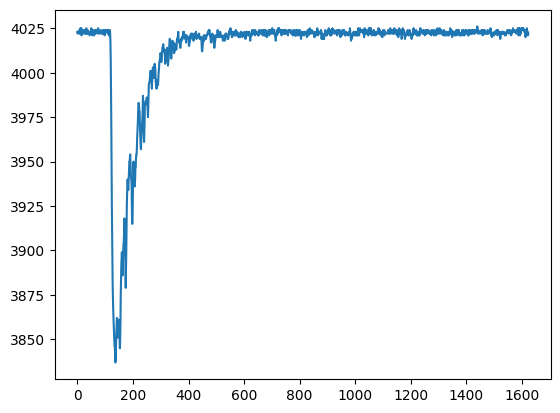

In [4]:
fig = plt.plot()

id = 0

event, event_attr = reader.GetEvent( id )

for key, val in event_attr.items():
    print( key, ':', val )

xdata = 0.004 * np.ones( len(event[channel]) )
plt.plot( event[channel] )
#plt.plot( event[index][:pre_trigger_window] )

- - -
# Pre-Trigger Window Baseline Fluctuation

- Plots the statistical distribution of fluctuation of the pre-trigger baseline
- For events with (very) large baseline fluctuations, the standard deviation and event index is recorded for later inspection

In [5]:
fluctuation = []
    # used to keep track of all standard deviations

opp_deviation = []
    # maximum opposite deviation from mean of pre-trigger baseline

event_list = []
    # used to pick out abnormal events with large fluctuation in baseline

event_list2 = []
    # used to pick out abnormal events that have large opposite fluctuation

counter = 0
std_threshold = 3

dev_threshold = 3 * std_threshold

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )
    
    tmp = np.std(event_data[channel][:pre_trigger_window-10])
    tmp2 = np.max(event_data[channel]) - np.mean(event_data[channel][:pre_trigger_window-10])
    
    fluctuation.append( tmp )

    opp_deviation.append( tmp2 )
    
    if tmp > std_threshold:
        event_list.append( (counter, tmp) )

    if tmp2 > dev_threshold:
        event_list2.append( (counter, tmp) )

    #if counter > 10000:
    #    break
        
    counter += 1

Processing event 173975

In [12]:
print( len(event_list) )
print( len(event_list2) )

312
255


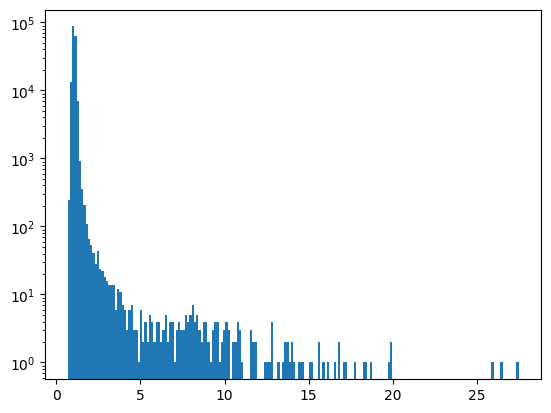

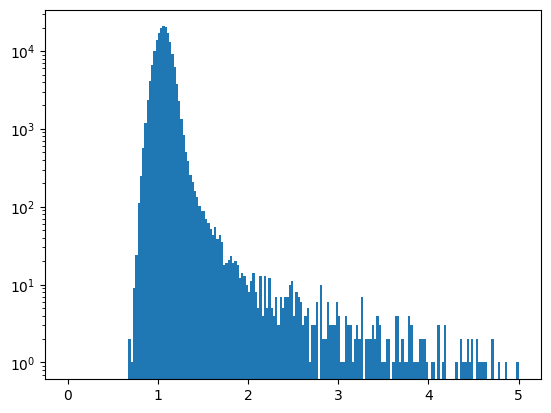

In [6]:
plt.figure()
plt.hist( fluctuation, bins=200 );
plt.yscale('log')

plt.figure()
plt.hist( fluctuation, bins=200, range=[0,5]);
plt.yscale('log')

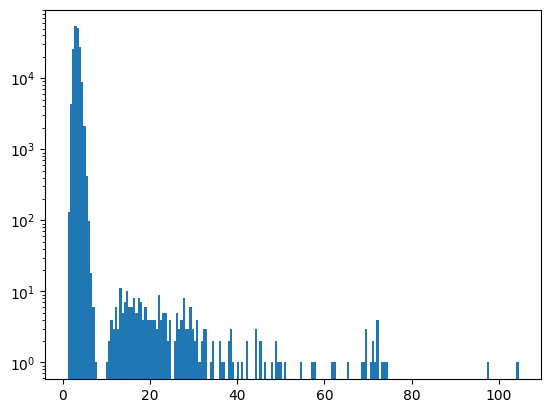

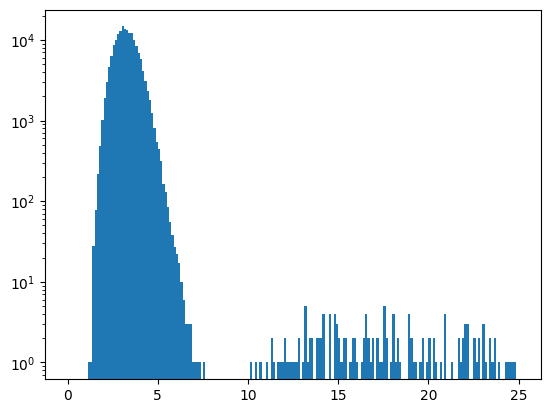

In [8]:
plt.figure()
plt.hist( opp_deviation, bins=200 );
plt.yscale('log')

plt.figure()
plt.hist( opp_deviation, bins=200, range=[0,25]);
plt.yscale('log')

## Conclusion

Most of the events have baseline standard deviation very small, on the order of 1. Therefore, setting the cutoff at 2 can already reject a lot of 
events.

---
## Pre-Trigger Window Baseline Fluctuation of a Reference Channel
The reference/noise-monitoring channel is left open and not connected to anything

In [11]:
fluctuation2 = []
counter = 0

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["counter"]), end='\r' )
    counter += 1
    
    fluctuation2.append( np.std(event_data[channel_ref][:pre_trigger_window]) )

Processing event 2752136

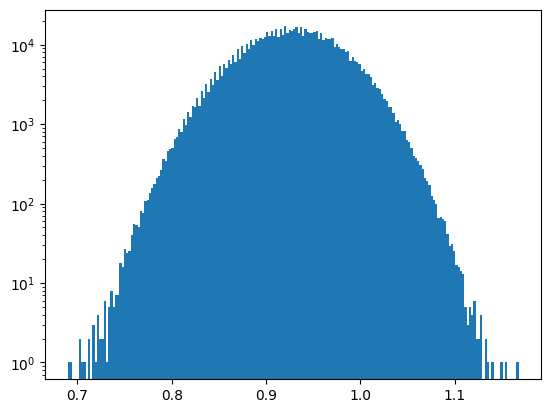

In [12]:
plt.figure()

plt.hist( fluctuation2, bins=200);
plt.yscale('log')

---
## Inspect the Abnormal Events with Large Standard Deviation in the Pre-Trigger Baseline

- it is realized that abnormally high standard deviation is due to pulse preceeding the trigger
- this is due to the pulse arriving within 1 microsecond (pre-trigger window) after the post trigger sample of previous event
    - in this case, the pre-trigger sample of the next event cannot be satisfied
    - the DAQ system will wait until the pulse decays close to the baseline, and when a fluctuation crosses the threshold, data is recorded

counter : 999096
index : 173975
option : 104
timestamp : 1742875577
trigger_time_tag : 3430635041


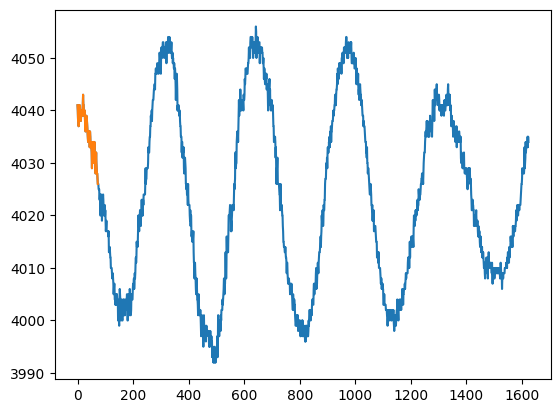


counter : 6906
index : 1192
option : 0
timestamp : 1742872002
trigger_time_tag : 3254115231


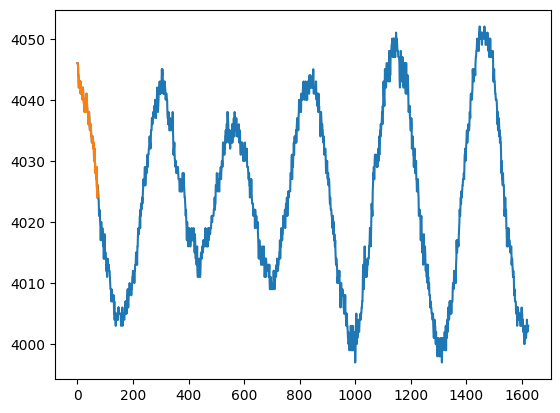


counter : 6918
index : 1193
option : 0
timestamp : 1742872002
trigger_time_tag : 3254116075


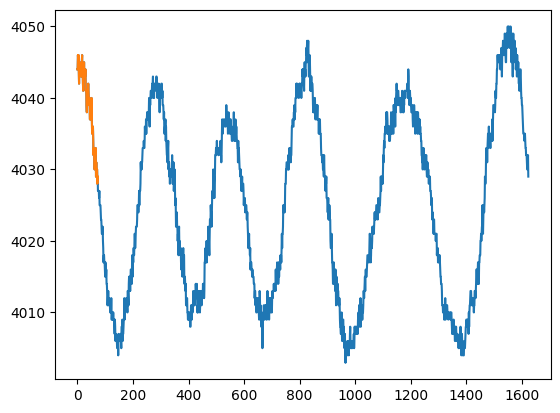


counter : 6930
index : 1194
option : 0
timestamp : 1742872002
trigger_time_tag : 3254116945


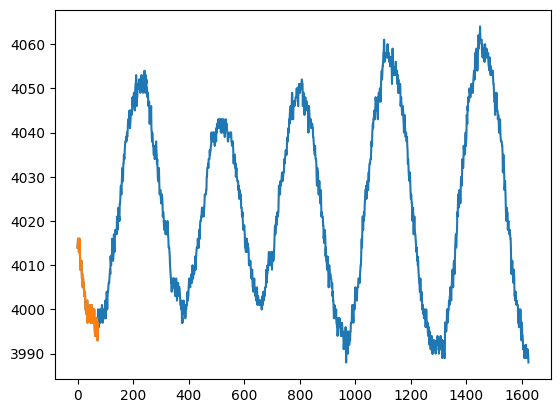


counter : 6950
index : 1195
option : 0
timestamp : 1742872002
trigger_time_tag : 3254117771


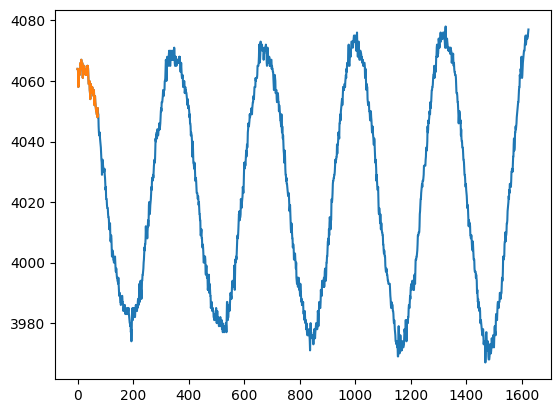


counter : 6960
index : 1196
option : 0
timestamp : 1742872002
trigger_time_tag : 3254118661


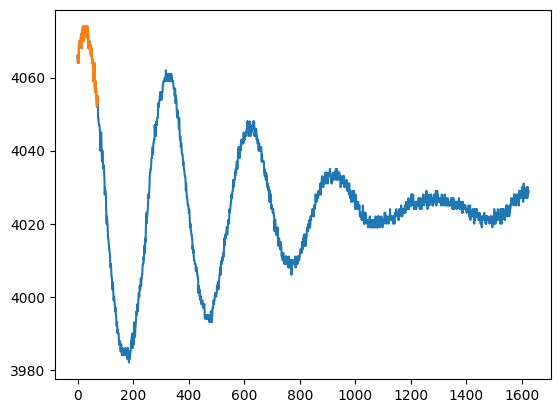


counter : 6968
index : 1197
option : 0
timestamp : 1742872002
trigger_time_tag : 3254119617


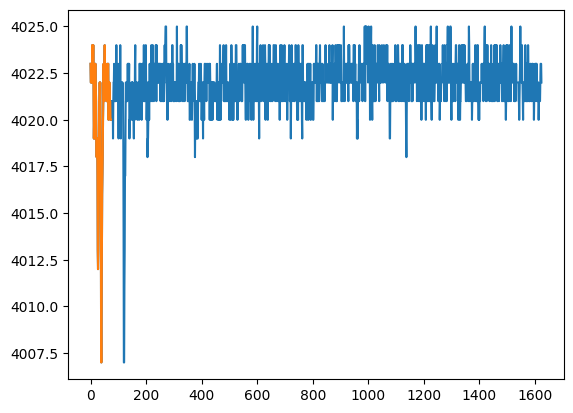


counter : 17784
index : 3081
option : 1
timestamp : 1742872041
trigger_time_tag : 3797697171


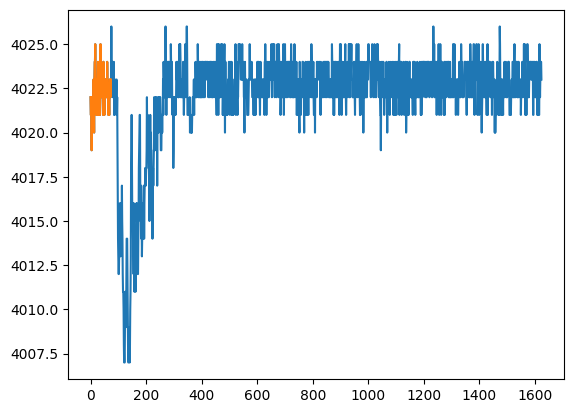


counter : 33704
index : 5817
option : 3
timestamp : 1742872097
trigger_time_tag : 2193933709


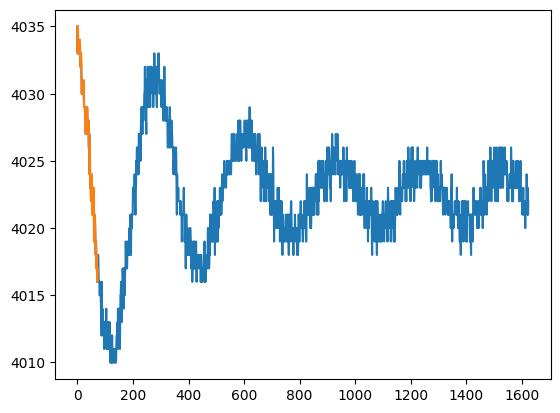


counter : 45600
index : 7887
option : 4
timestamp : 1742872139
trigger_time_tag : 3229051343


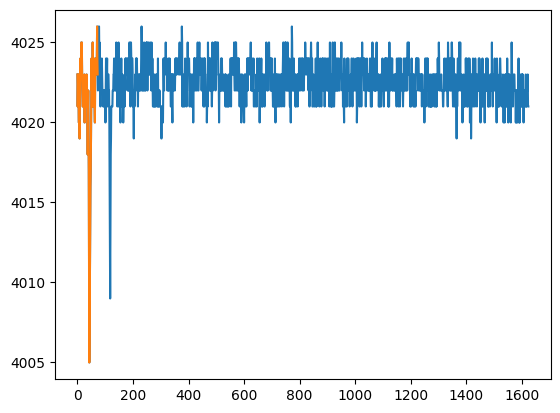

In [9]:
# plot a few problematic events

counter_min = 0
counter_max = 10

for n,(i,j) in enumerate(event_list):

    if n > counter_min and n <= counter_max:
        
        for k,v in event_attr.items():
            print( k, ":", v )
        
        plt.figure()
        event, event_attr = reader.GetEvent( i )
        plt.plot( event[channel] )
        plt.plot( event[channel][:pre_trigger_window-50] )
        plt.show()

        print()
    
    if n >= counter_max:
        break

counter : 45583
index : 7886
option : 4
timestamp : 1742872139
trigger_time_tag : 3229050487


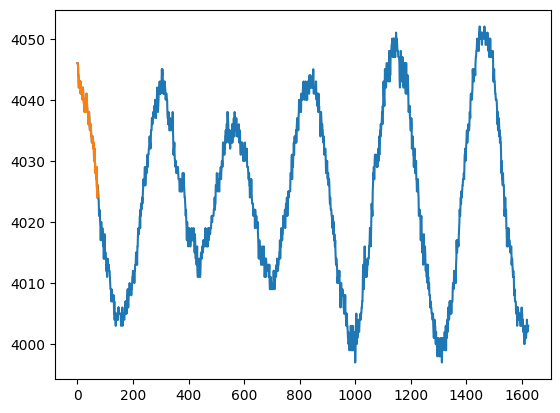


counter : 6918
index : 1193
option : 0
timestamp : 1742872002
trigger_time_tag : 3254116075


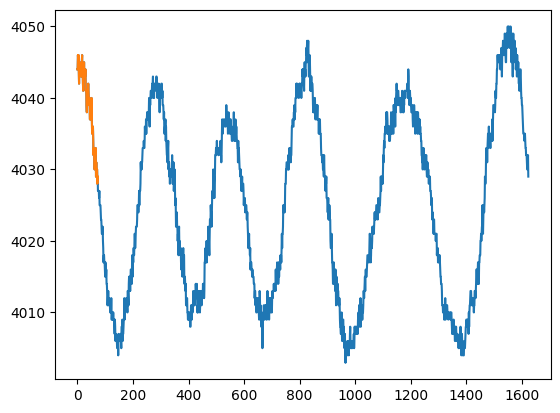


counter : 6930
index : 1194
option : 0
timestamp : 1742872002
trigger_time_tag : 3254116945


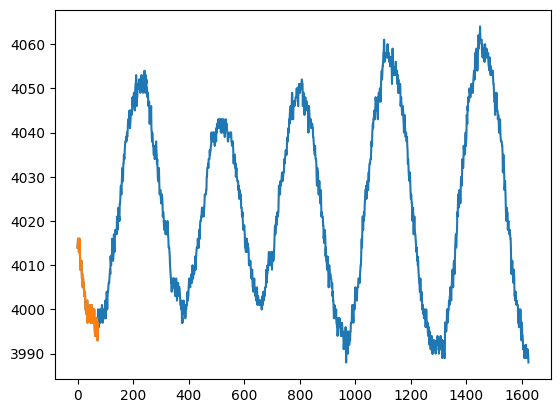


counter : 6950
index : 1195
option : 0
timestamp : 1742872002
trigger_time_tag : 3254117771


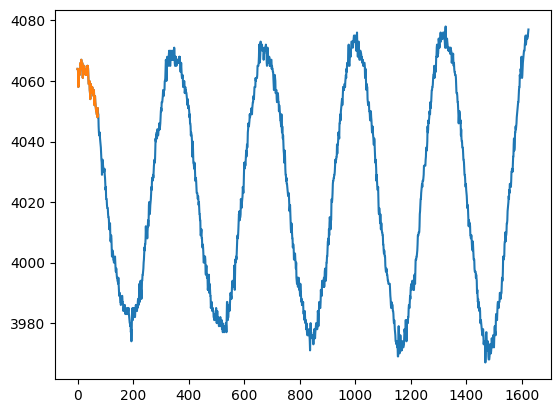


counter : 6960
index : 1196
option : 0
timestamp : 1742872002
trigger_time_tag : 3254118661


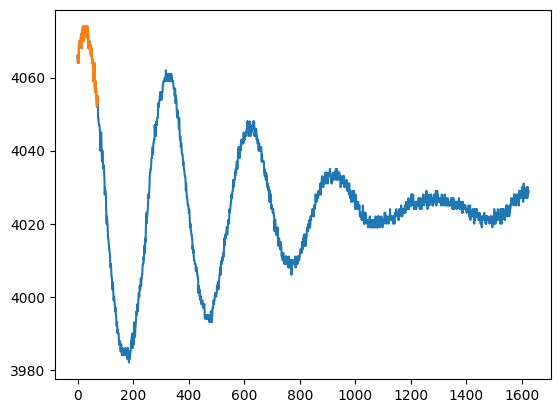


counter : 6968
index : 1197
option : 0
timestamp : 1742872002
trigger_time_tag : 3254119617


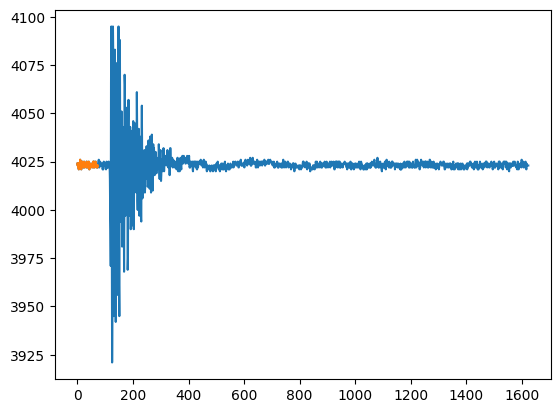


counter : 29449
index : 5102
option : 3
timestamp : 1742872082
trigger_time_tag : 392255447


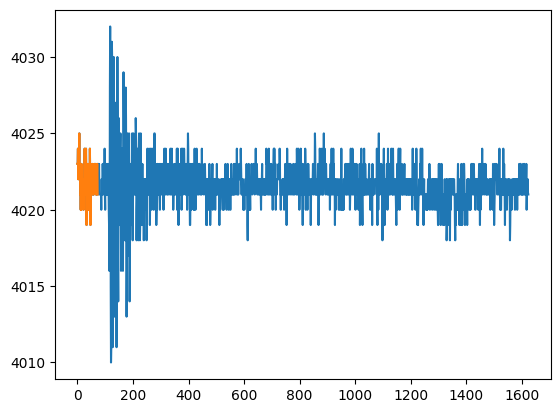


counter : 29497
index : 5109
option : 3
timestamp : 1742872082
trigger_time_tag : 402446515


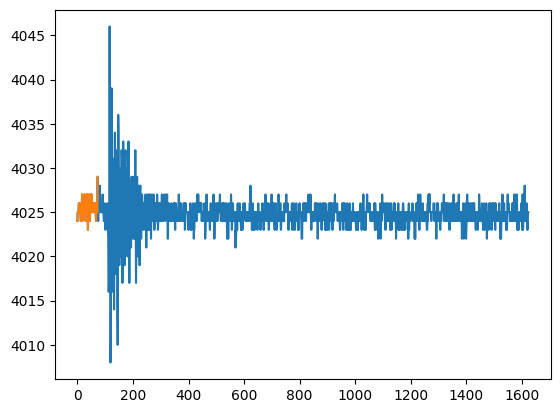


counter : 31319
index : 5418
option : 3
timestamp : 1742872089
trigger_time_tag : 1235403415


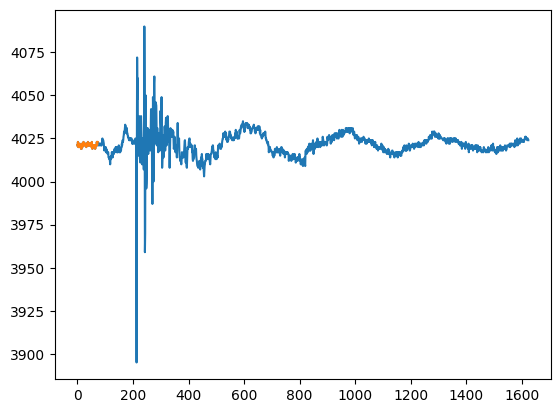


counter : 45567
index : 7885
option : 4
timestamp : 1742872139
trigger_time_tag : 3229035263


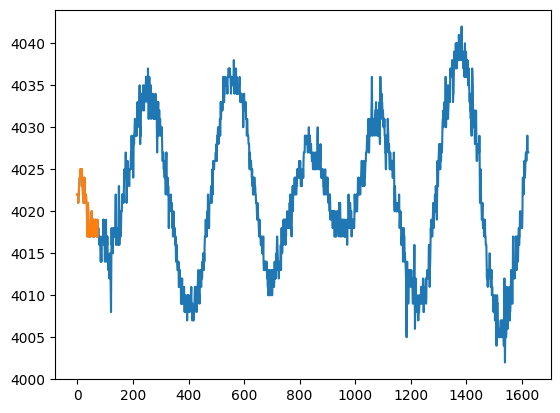


counter : 45583
index : 7886
option : 4
timestamp : 1742872139
trigger_time_tag : 3229050487


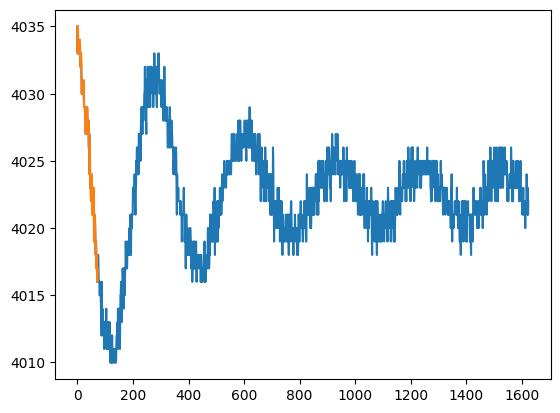


counter : 45600
index : 7887
option : 4
timestamp : 1742872139
trigger_time_tag : 3229051343


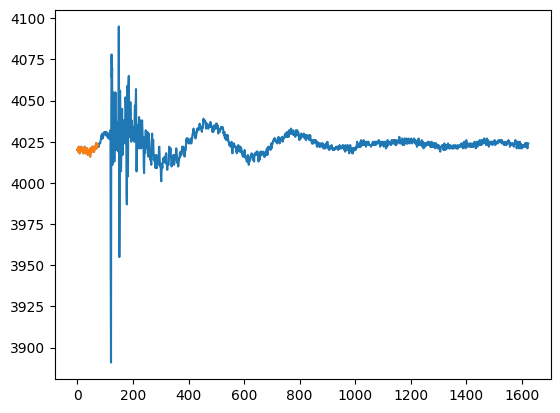


counter : 83492
index : 14453
option : 8
timestamp : 1742872276
trigger_time_tag : 3142162187


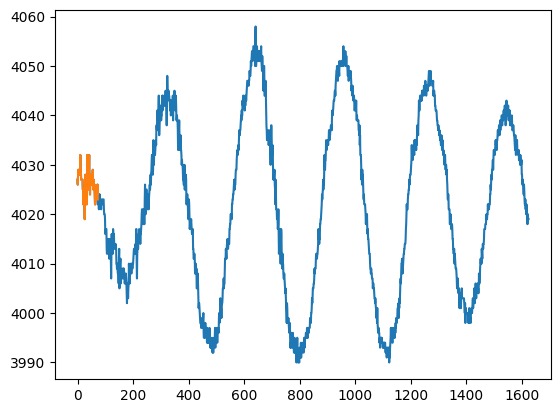


counter : 83504
index : 14454
option : 8
timestamp : 1742872276
trigger_time_tag : 3142172073


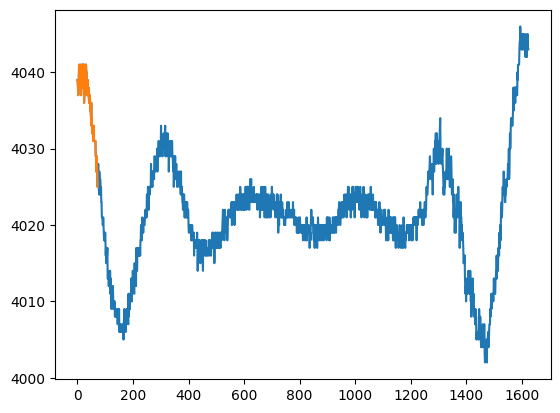


counter : 83515
index : 14455
option : 8
timestamp : 1742872276
trigger_time_tag : 3142172983


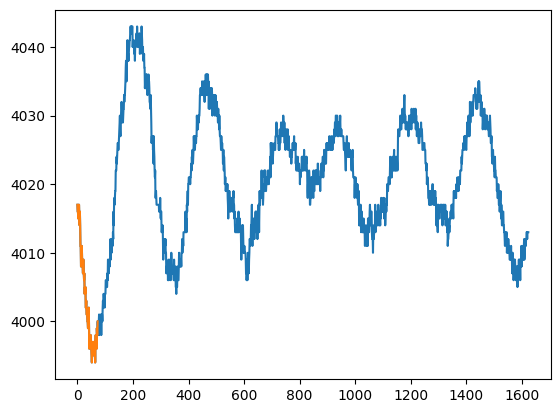


counter : 83524
index : 14456
option : 8
timestamp : 1742872276
trigger_time_tag : 3142173829


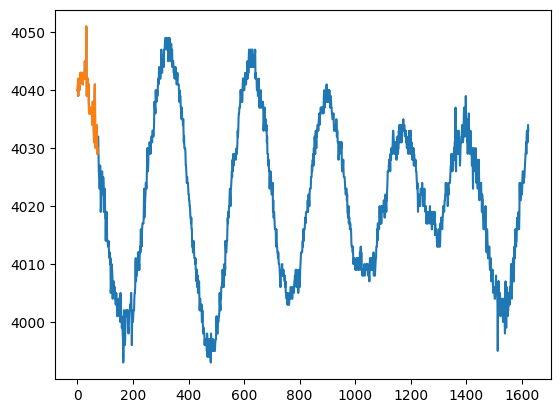


counter : 83535
index : 14457
option : 8
timestamp : 1742872276
trigger_time_tag : 3142174683


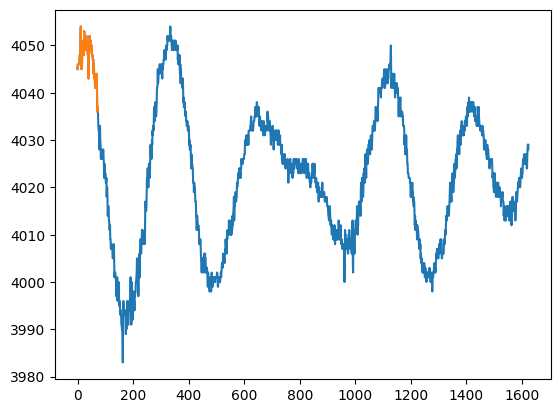


counter : 83549
index : 14458
option : 8
timestamp : 1742872276
trigger_time_tag : 3142175511


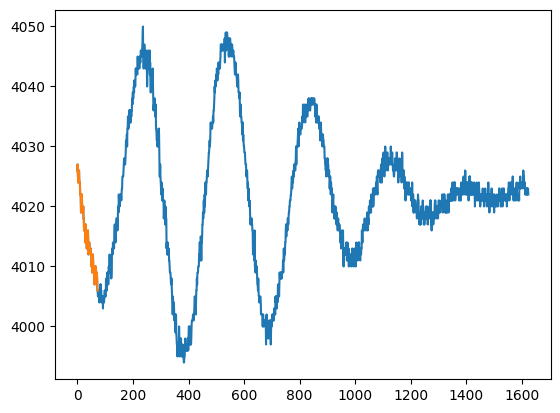


counter : 83562
index : 14459
option : 8
timestamp : 1742872276
trigger_time_tag : 3142176359


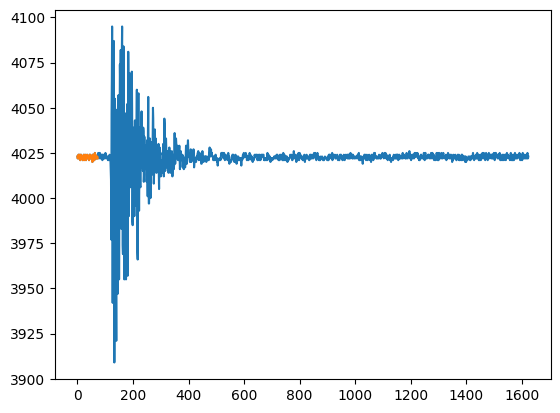


counter : 89563
index : 15488
option : 9
timestamp : 1742872298
trigger_time_tag : 1578797029


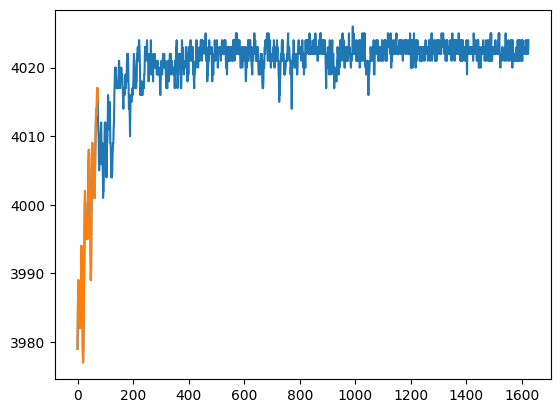


counter : 96393
index : 16654
option : 10
timestamp : 1742872322
trigger_time_tag : 265827279


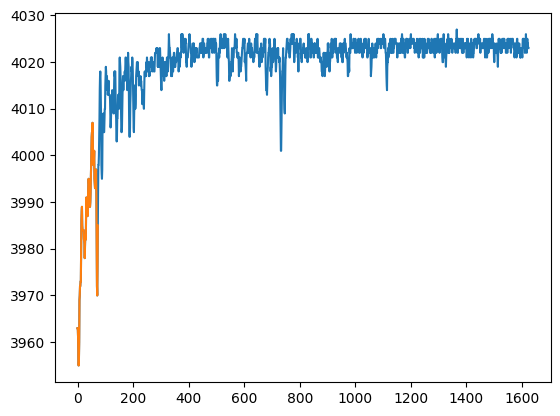


counter : 98401
index : 17011
option : 10
timestamp : 1742872330
trigger_time_tag : 1306381655


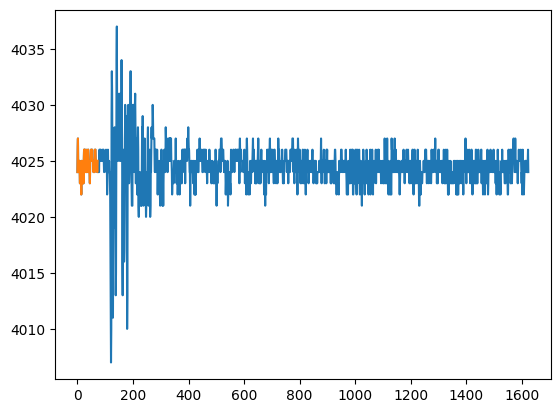


counter : 112338
index : 19388
option : 11
timestamp : 1742872379
trigger_time_tag : 3131498185


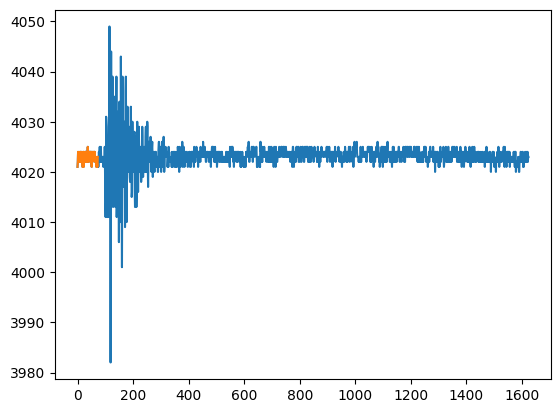


counter : 112625
index : 19441
option : 11
timestamp : 1742872380
trigger_time_tag : 3272393345


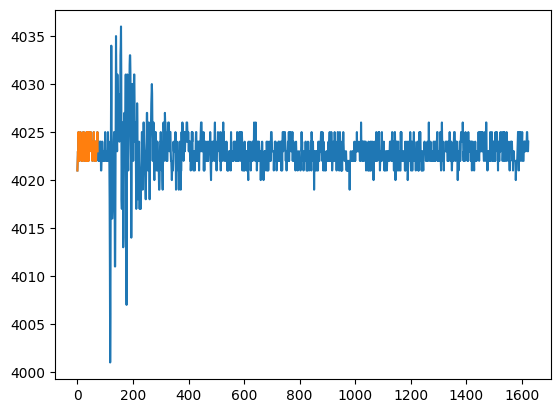


counter : 112724
index : 19455
option : 11
timestamp : 1742872380
trigger_time_tag : 3295474583


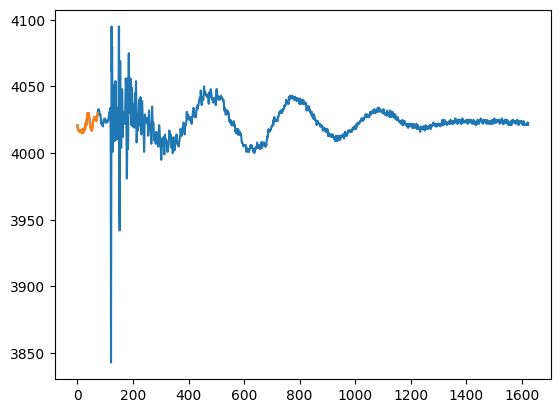


counter : 122114
index : 21076
option : 12
timestamp : 1742872413
trigger_time_tag : 3049962761


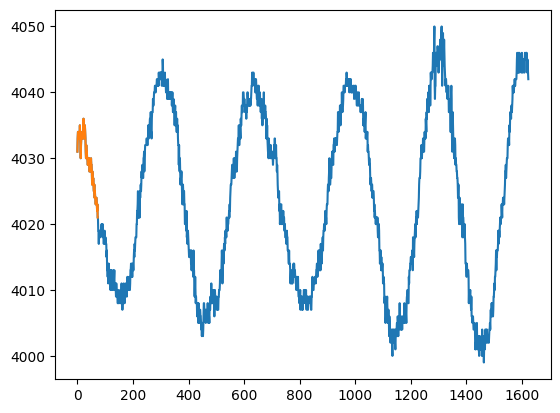


counter : 122135
index : 21077
option : 12
timestamp : 1742872413
trigger_time_tag : 3049963695


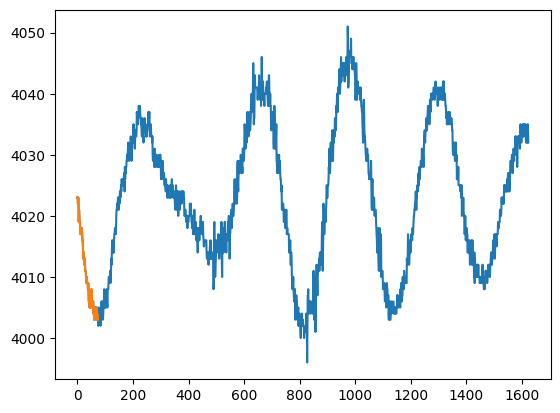


counter : 122150
index : 21078
option : 12
timestamp : 1742872413
trigger_time_tag : 3049964537


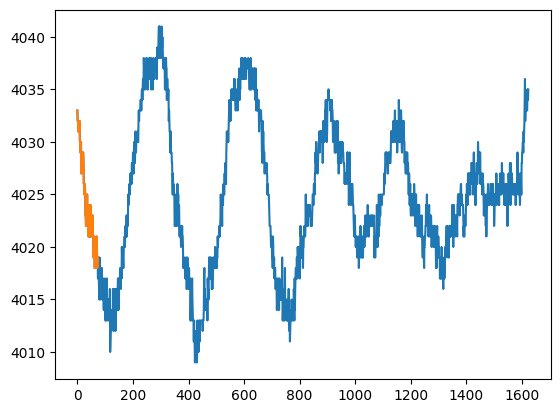


counter : 122163
index : 21079
option : 12
timestamp : 1742872413
trigger_time_tag : 3050016233


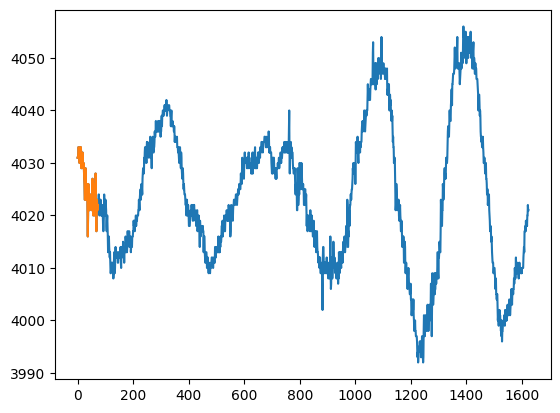


counter : 122165
index : 21080
option : 12
timestamp : 1742872413
trigger_time_tag : 3050017049


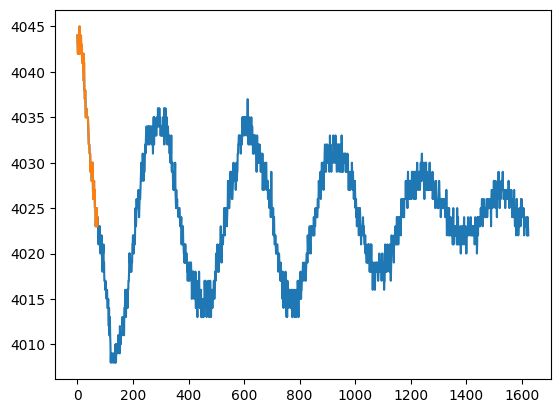


counter : 122181
index : 21081
option : 12
timestamp : 1742872413
trigger_time_tag : 3050017897


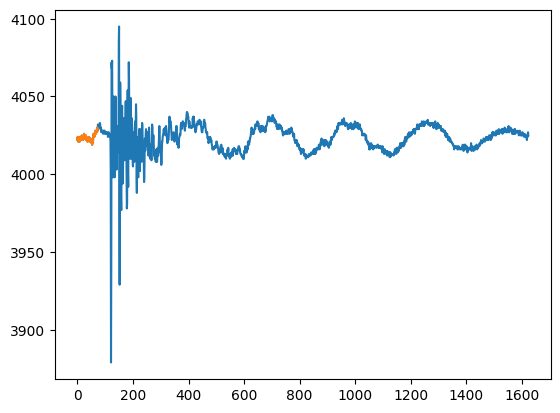


counter : 160263
index : 27680
option : 16
timestamp : 1742872549
trigger_time_tag : 2870976359


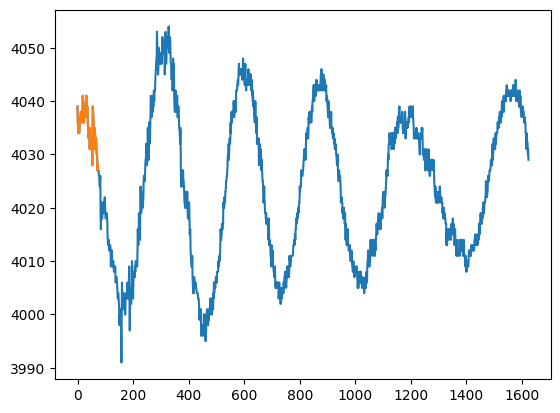


counter : 160281
index : 27681
option : 16
timestamp : 1742872549
trigger_time_tag : 2870987075


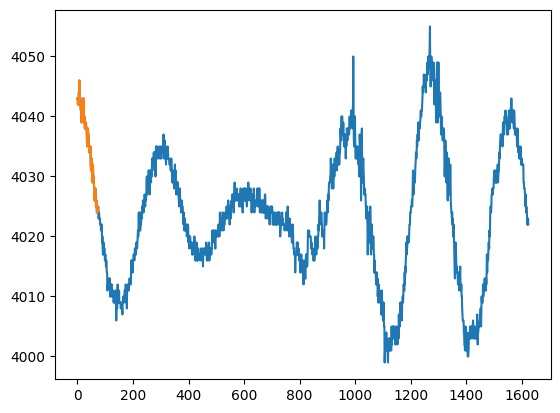


counter : 160291
index : 27682
option : 16
timestamp : 1742872549
trigger_time_tag : 2870988015


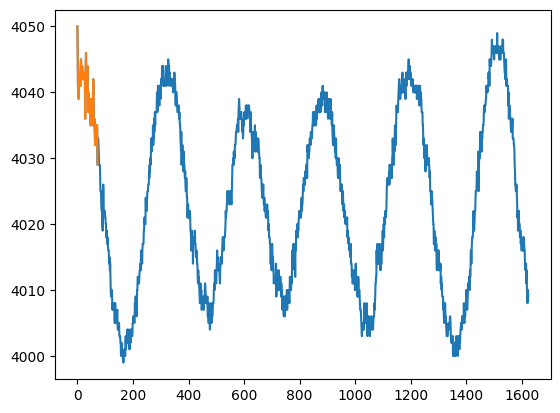


counter : 160302
index : 27683
option : 16
timestamp : 1742872549
trigger_time_tag : 2870988921


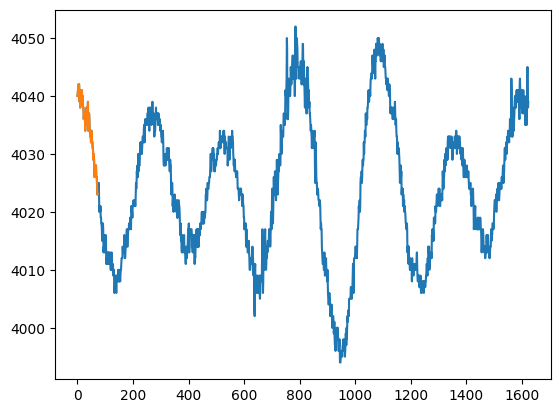


counter : 160314
index : 27684
option : 16
timestamp : 1742872549
trigger_time_tag : 2870989819


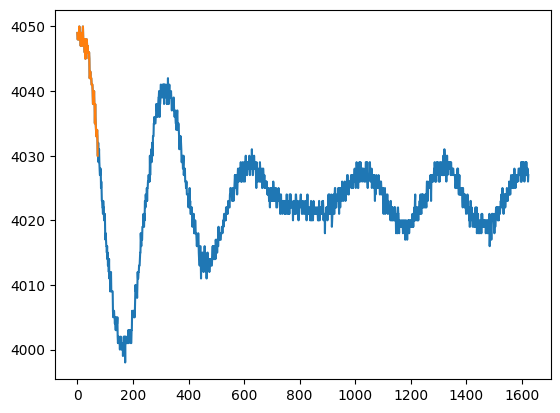


counter : 160328
index : 27685
option : 16
timestamp : 1742872549
trigger_time_tag : 2870990755


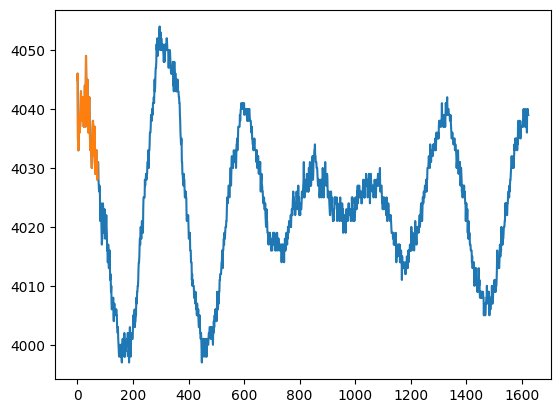


counter : 197969
index : 34270
option : 20
timestamp : 1742872685
trigger_time_tag : 2726606261


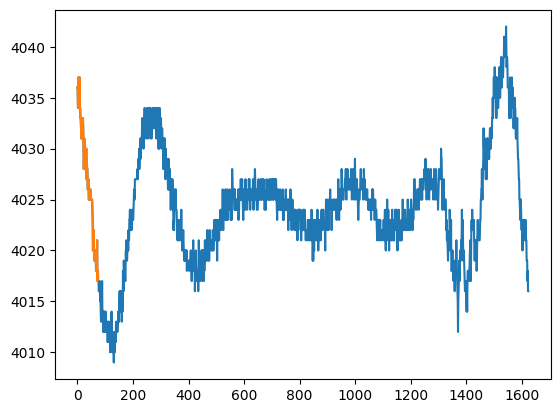


counter : 197974
index : 34271
option : 20
timestamp : 1742872685
trigger_time_tag : 2726607083


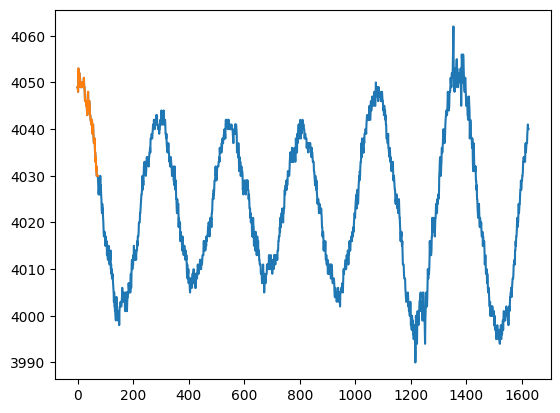


counter : 197978
index : 34272
option : 20
timestamp : 1742872685
trigger_time_tag : 2726607989


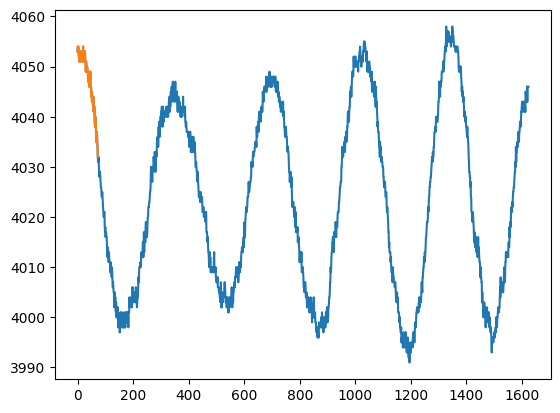


counter : 197993
index : 34273
option : 20
timestamp : 1742872685
trigger_time_tag : 2726608819


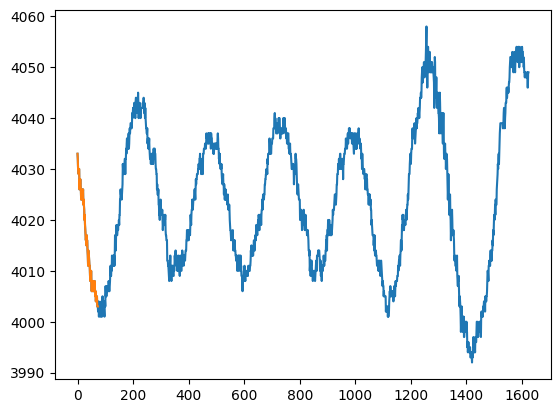


counter : 198002
index : 34274
option : 20
timestamp : 1742872685
trigger_time_tag : 2726609663


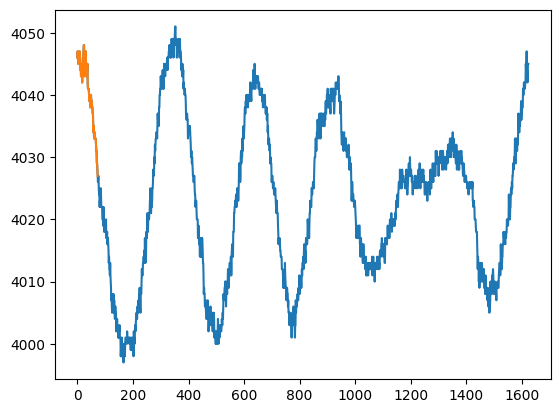


counter : 198019
index : 34275
option : 20
timestamp : 1742872685
trigger_time_tag : 2726610639


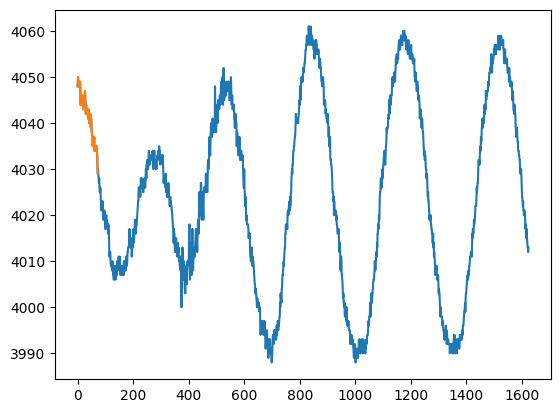


counter : 198030
index : 34276
option : 20
timestamp : 1742872685
trigger_time_tag : 2726611605


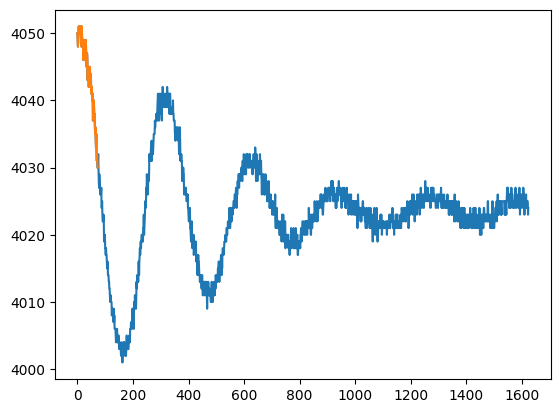


counter : 198041
index : 34277
option : 20
timestamp : 1742872685
trigger_time_tag : 2726612521


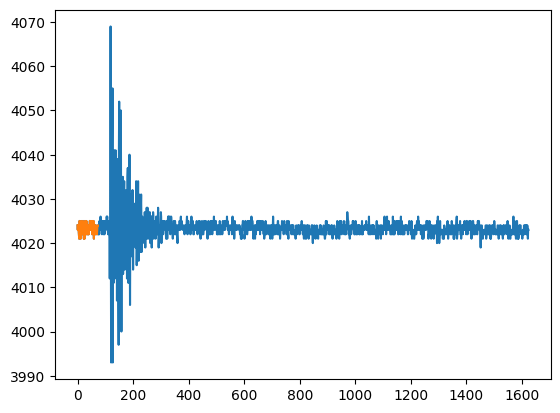


counter : 231239
index : 40022
option : 24
timestamp : 1742872805
trigger_time_tag : 508030357


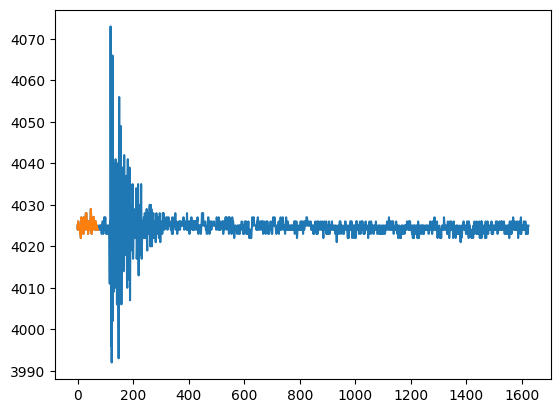


counter : 231265
index : 40026
option : 24
timestamp : 1742872805
trigger_time_tag : 521575737


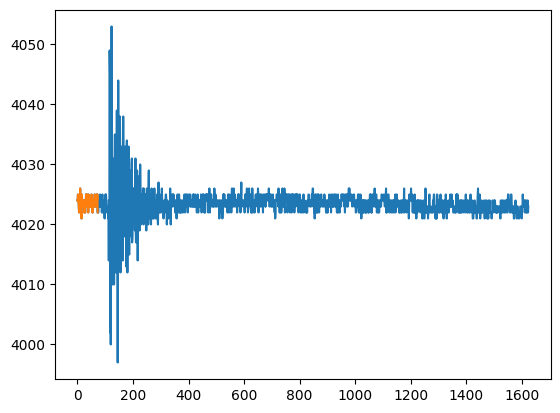


counter : 231346
index : 40039
option : 24
timestamp : 1742872805
trigger_time_tag : 542266671


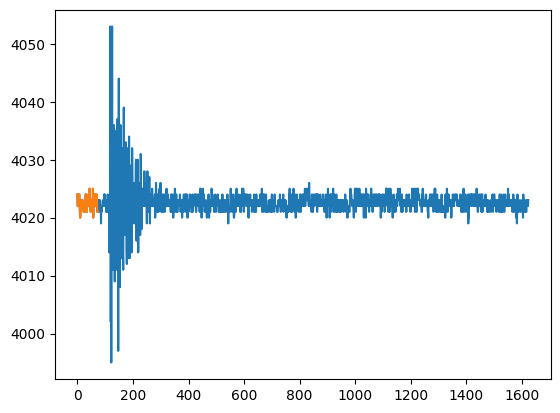


counter : 231527
index : 40078
option : 24
timestamp : 1742872806
trigger_time_tag : 636544689


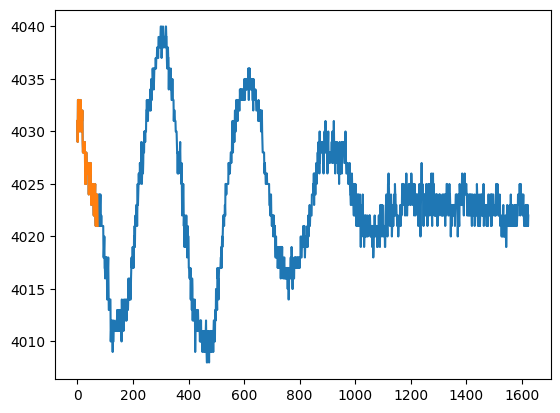


counter : 236249
index : 40873
option : 24
timestamp : 1742872822
trigger_time_tag : 2667055909


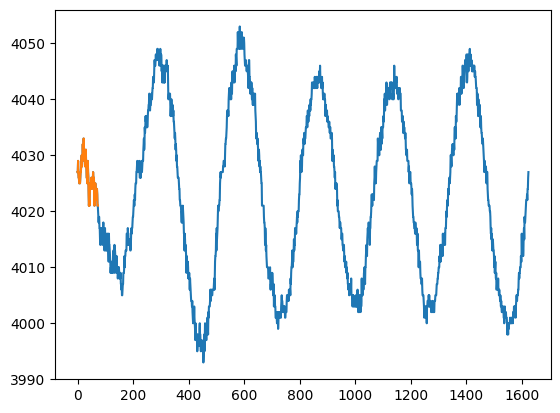


counter : 236257
index : 40874
option : 24
timestamp : 1742872822
trigger_time_tag : 2667064289


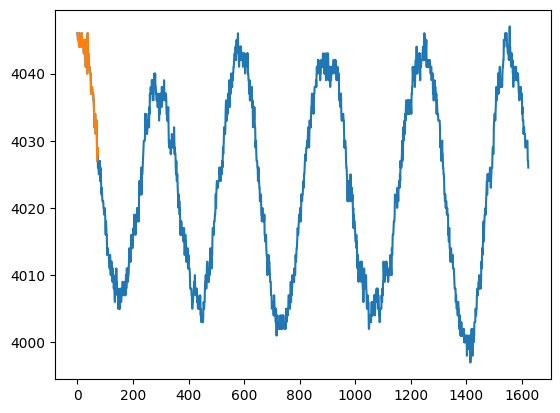


counter : 236269
index : 40875
option : 24
timestamp : 1742872822
trigger_time_tag : 2667065133


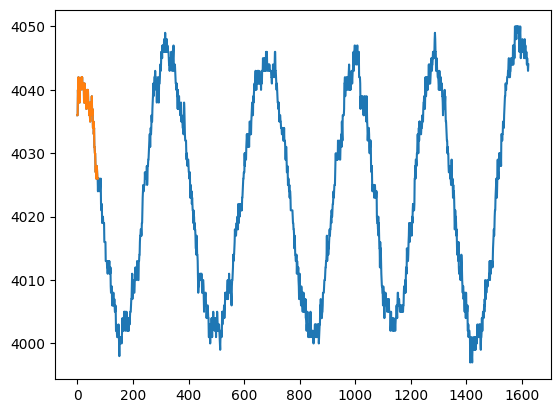


counter : 236287
index : 40876
option : 24
timestamp : 1742872822
trigger_time_tag : 2667066041


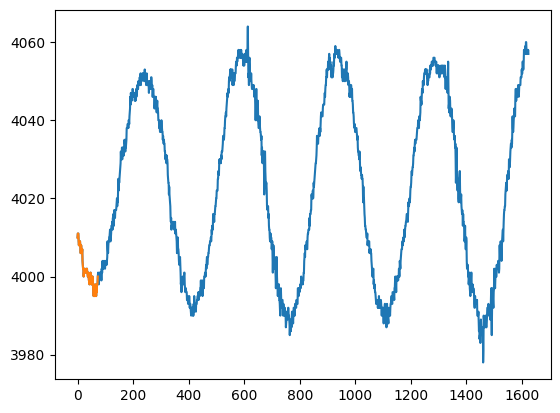


counter : 236300
index : 40877
option : 24
timestamp : 1742872822
trigger_time_tag : 2667066893


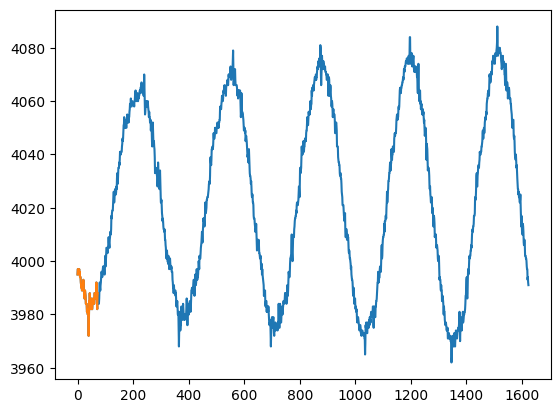


counter : 236307
index : 40878
option : 24
timestamp : 1742872822
trigger_time_tag : 2667067769


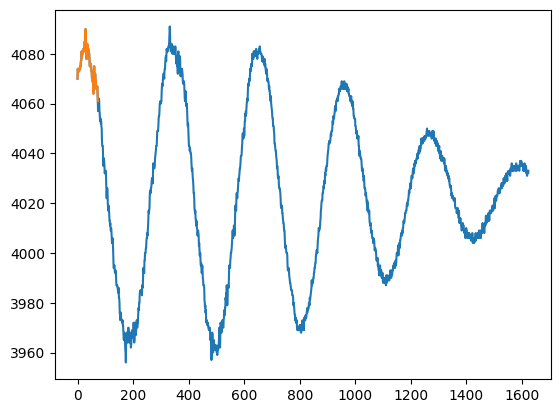


counter : 236316
index : 40879
option : 24
timestamp : 1742872822
trigger_time_tag : 2667068669


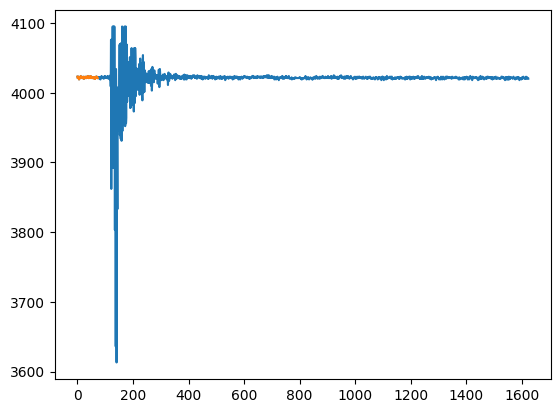


counter : 237017
index : 40996
option : 24
timestamp : 1742872825
trigger_time_tag : 2983177253


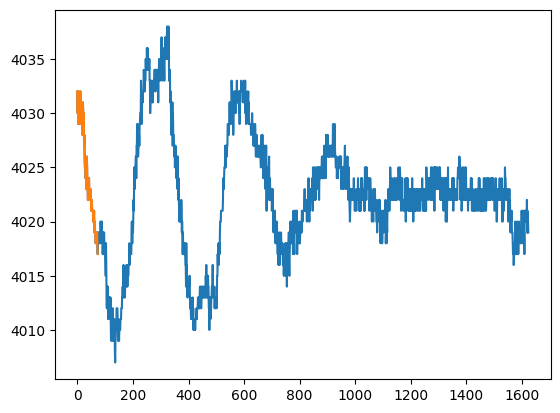


counter : 274948
index : 47572
option : 28
timestamp : 1742872959
trigger_time_tag : 2572176273


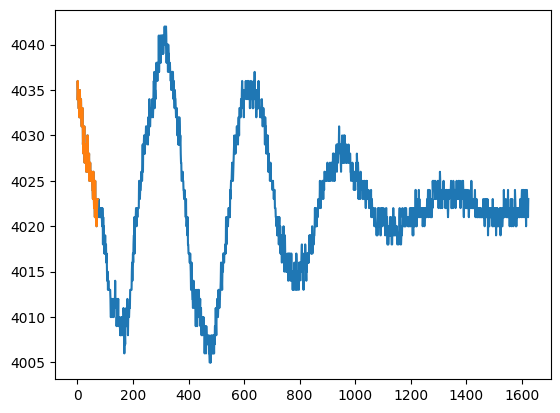


counter : 274954
index : 47573
option : 28
timestamp : 1742872959
trigger_time_tag : 2572177157


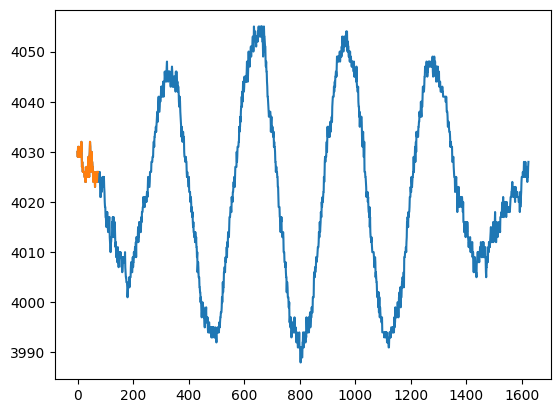


counter : 274964
index : 47574
option : 28
timestamp : 1742872959
trigger_time_tag : 2572188547


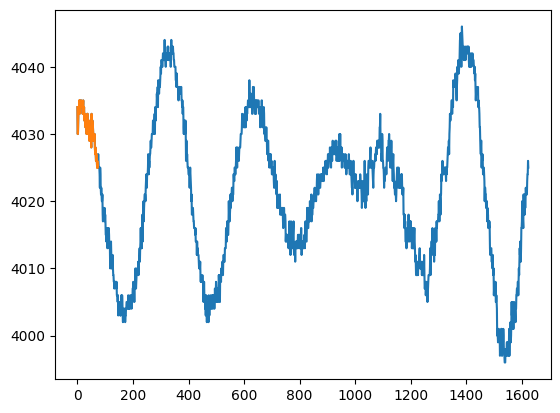


counter : 274976
index : 47575
option : 28
timestamp : 1742872959
trigger_time_tag : 2572189395


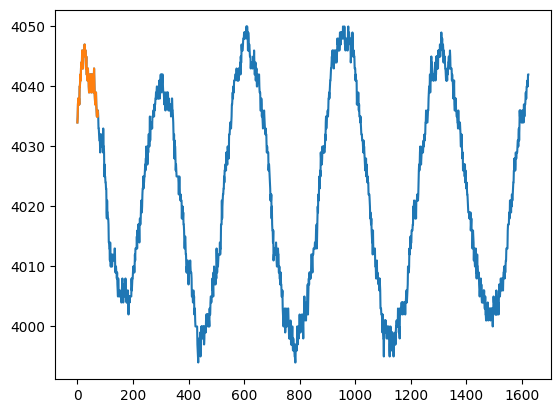


counter : 274984
index : 47576
option : 28
timestamp : 1742872959
trigger_time_tag : 2572190221


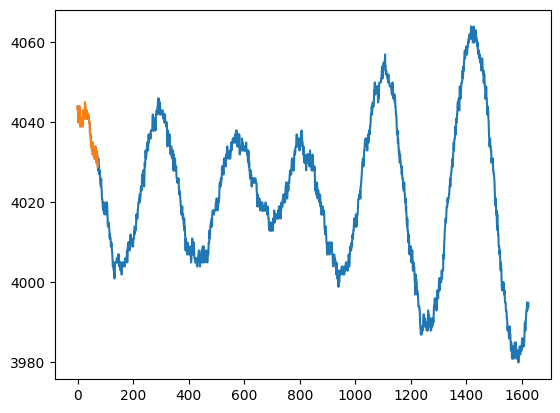


counter : 274995
index : 47577
option : 28
timestamp : 1742872959
trigger_time_tag : 2572191037


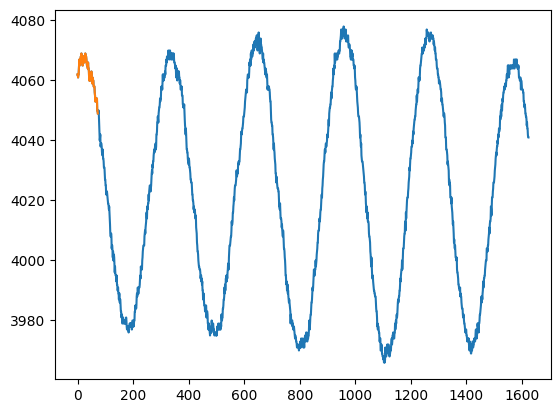


counter : 275002
index : 47578
option : 28
timestamp : 1742872959
trigger_time_tag : 2572191895


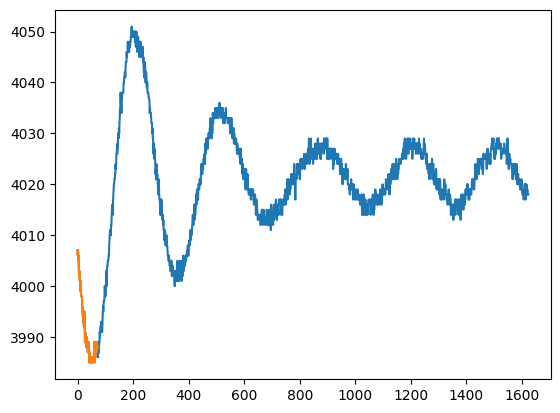


counter : 275009
index : 47579
option : 28
timestamp : 1742872959
trigger_time_tag : 2572192727


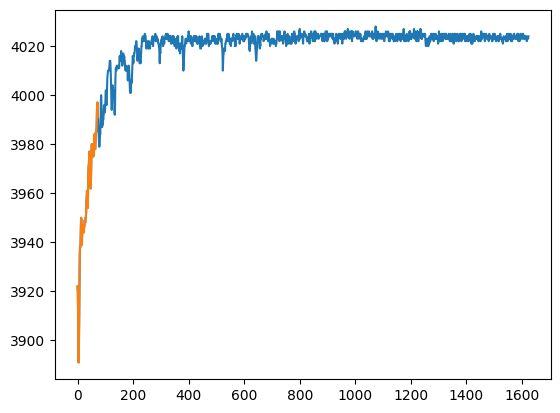


counter : 282116
index : 48822
option : 29
timestamp : 1742872985
trigger_time_tag : 1520678101


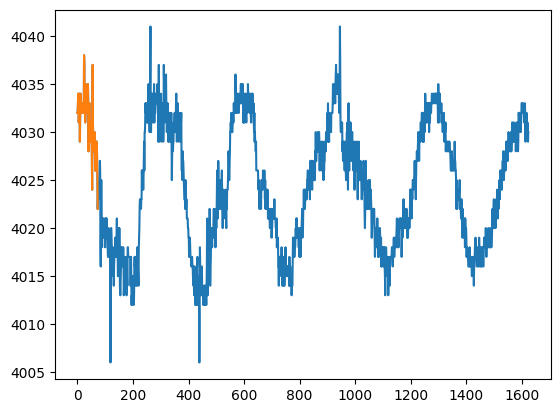


counter : 312275
index : 54078
option : 32
timestamp : 1742873096
trigger_time_tag : 2604655537


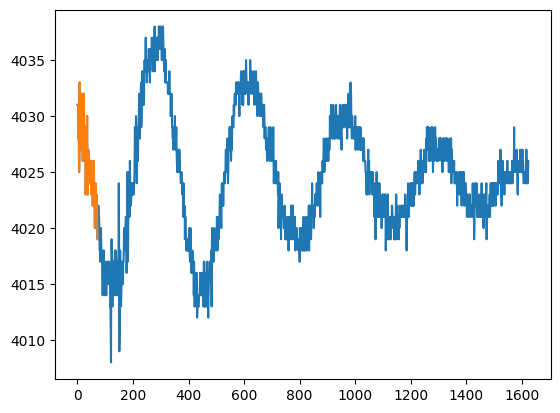


counter : 312277
index : 54079
option : 32
timestamp : 1742873096
trigger_time_tag : 2604682853


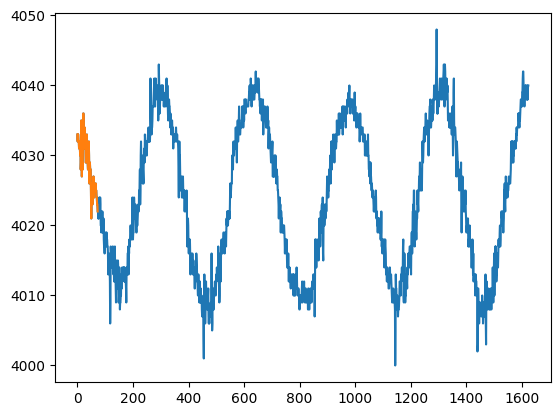


counter : 312279
index : 54080
option : 32
timestamp : 1742873096
trigger_time_tag : 2604687639


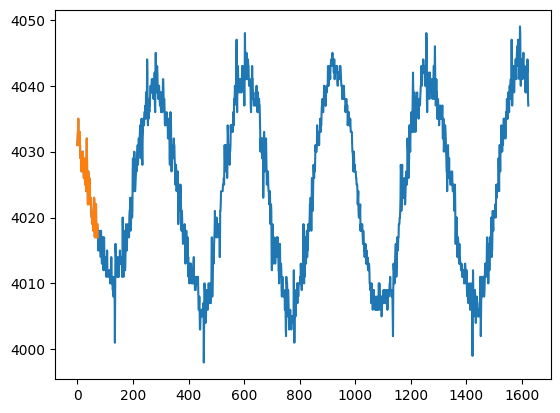


counter : 312305
index : 54081
option : 32
timestamp : 1742873096
trigger_time_tag : 2604688669


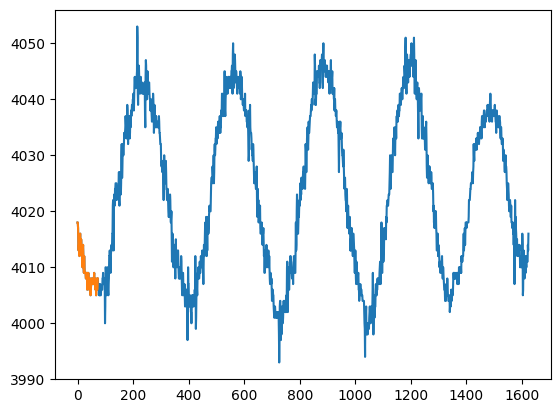


counter : 312327
index : 54082
option : 32
timestamp : 1742873096
trigger_time_tag : 2604689517


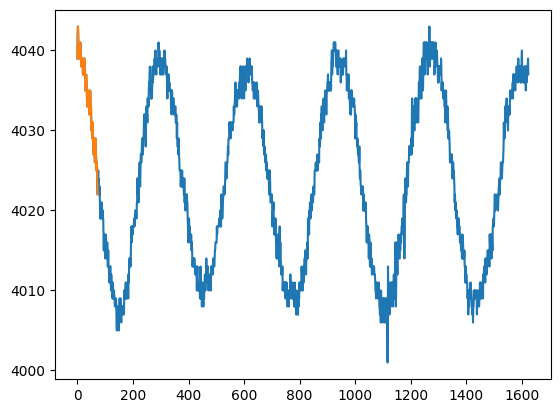


counter : 312347
index : 54083
option : 32
timestamp : 1742873096
trigger_time_tag : 2604690395


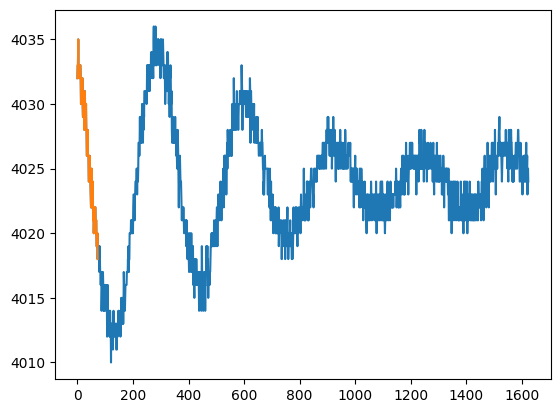


counter : 312371
index : 54084
option : 32
timestamp : 1742873096
trigger_time_tag : 2604691401


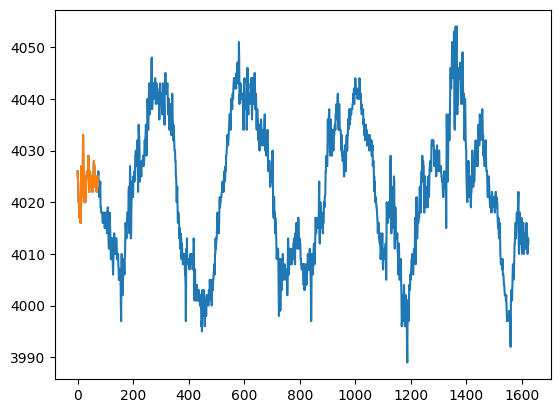


counter : 312372
index : 54085
option : 32
timestamp : 1742873096
trigger_time_tag : 2604707573


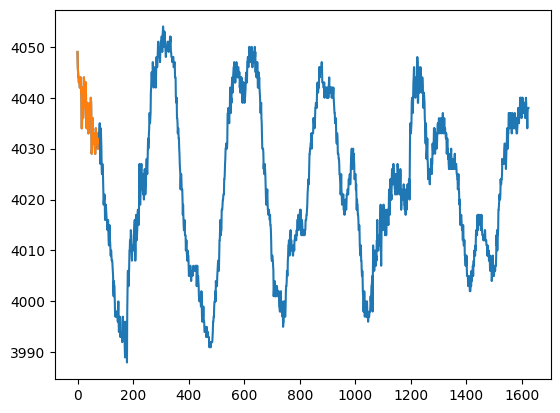


counter : 312398
index : 54086
option : 32
timestamp : 1742873096
trigger_time_tag : 2604708429


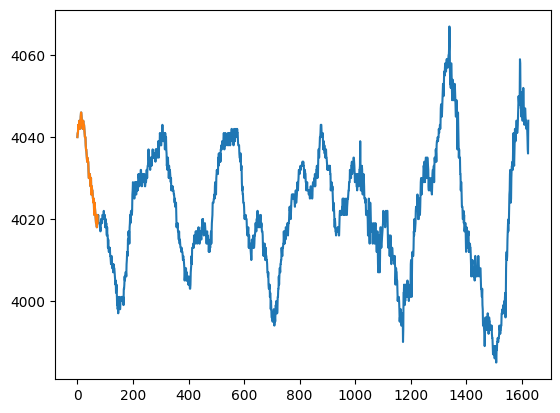


counter : 312416
index : 54087
option : 32
timestamp : 1742873096
trigger_time_tag : 2604709377


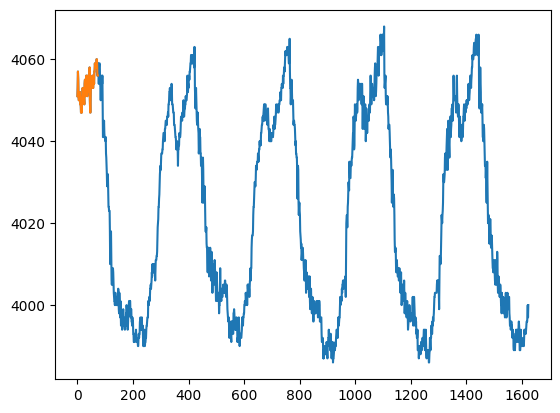


counter : 312430
index : 54088
option : 32
timestamp : 1742873096
trigger_time_tag : 2604710347


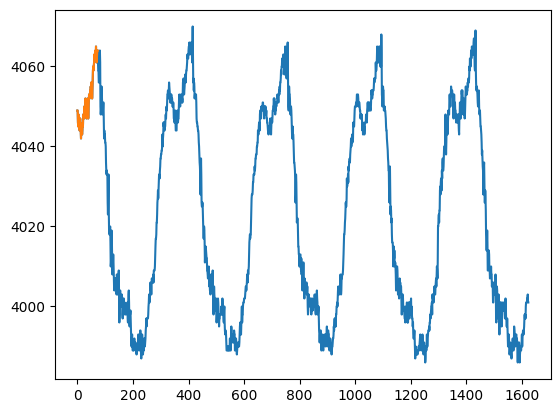


counter : 312440
index : 54089
option : 32
timestamp : 1742873096
trigger_time_tag : 2604711199


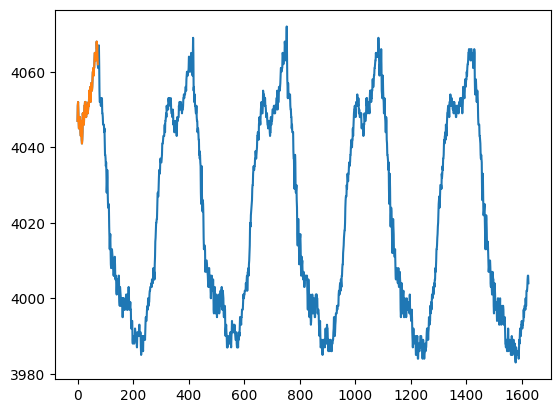


counter : 312449
index : 54090
option : 32
timestamp : 1742873096
trigger_time_tag : 2604712047


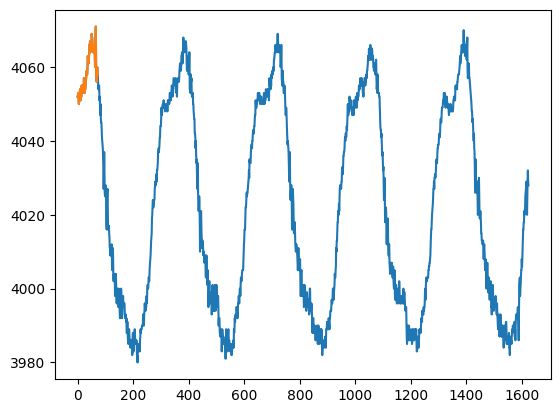


counter : 312456
index : 54091
option : 32
timestamp : 1742873096
trigger_time_tag : 2604712895


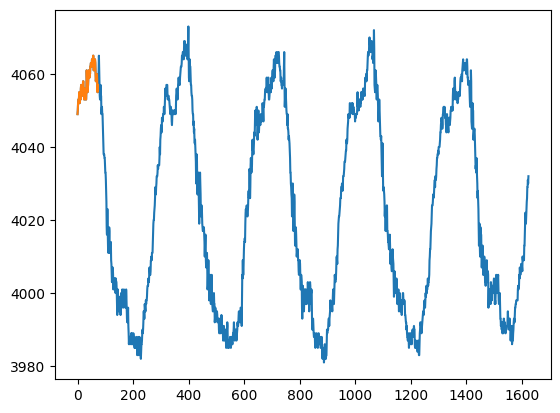


counter : 312463
index : 54092
option : 32
timestamp : 1742873096
trigger_time_tag : 2604713731


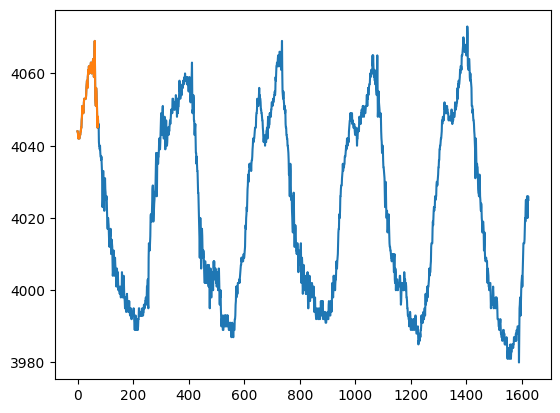


counter : 312469
index : 54093
option : 32
timestamp : 1742873096
trigger_time_tag : 2604714571


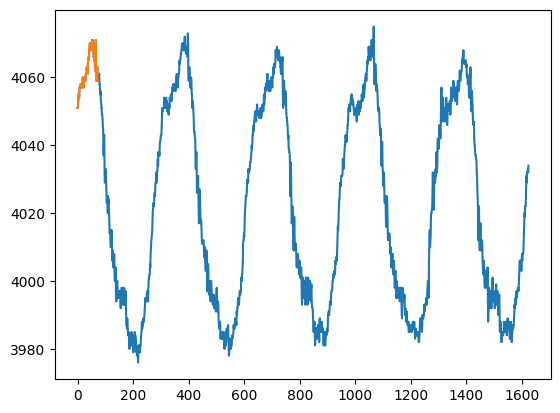


counter : 312477
index : 54094
option : 32
timestamp : 1742873096
trigger_time_tag : 2604715407


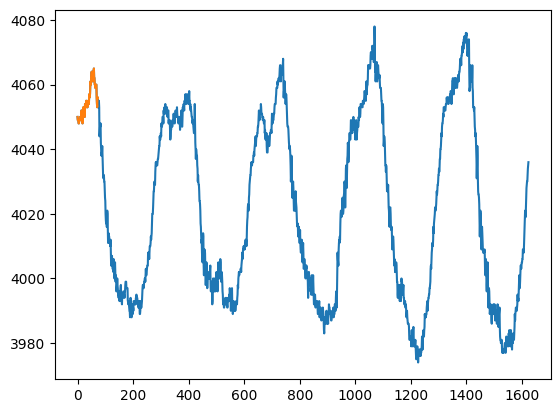


counter : 312484
index : 54095
option : 32
timestamp : 1742873096
trigger_time_tag : 2604716243


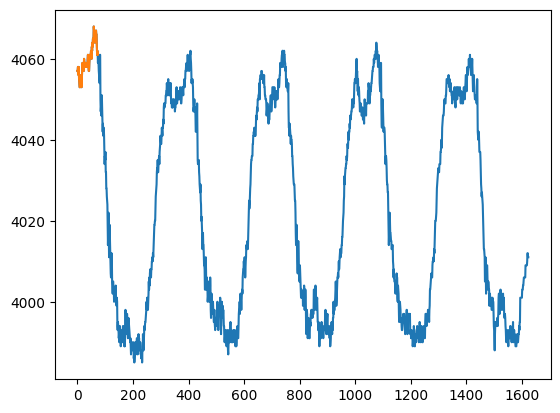


counter : 312494
index : 54096
option : 32
timestamp : 1742873096
trigger_time_tag : 2604717077


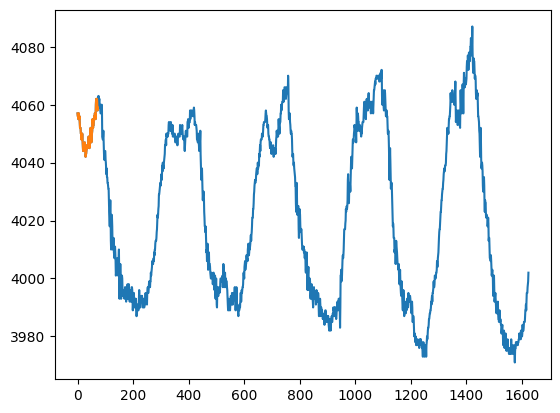


counter : 312501
index : 54097
option : 32
timestamp : 1742873096
trigger_time_tag : 2604717915


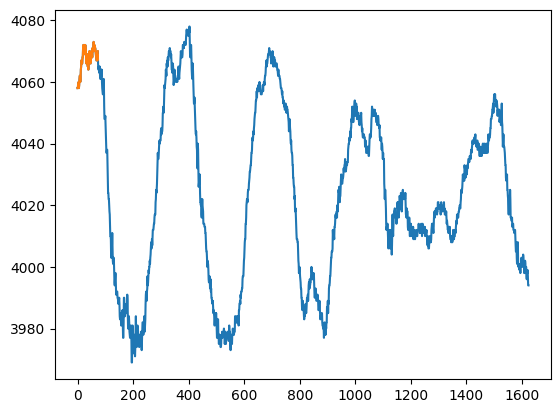


counter : 312511
index : 54098
option : 32
timestamp : 1742873096
trigger_time_tag : 2604718759


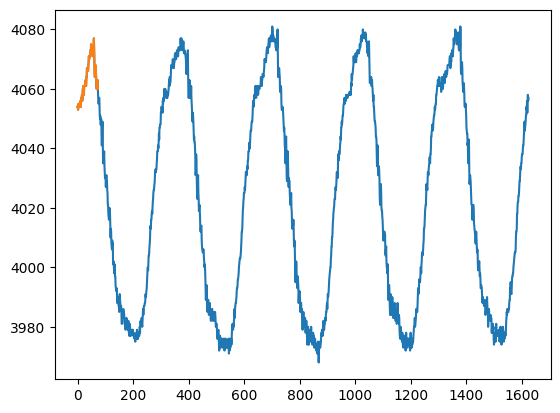


counter : 312526
index : 54099
option : 32
timestamp : 1742873096
trigger_time_tag : 2604719647


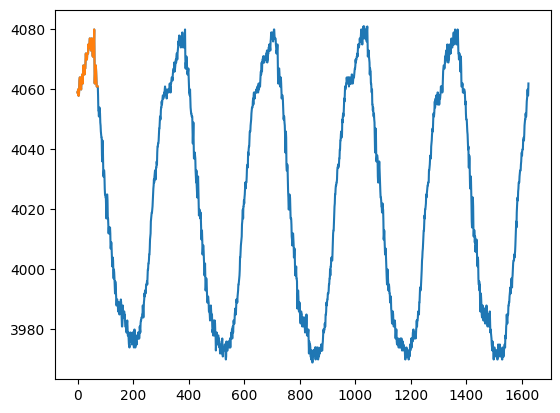


counter : 312532
index : 54100
option : 32
timestamp : 1742873096
trigger_time_tag : 2604720471


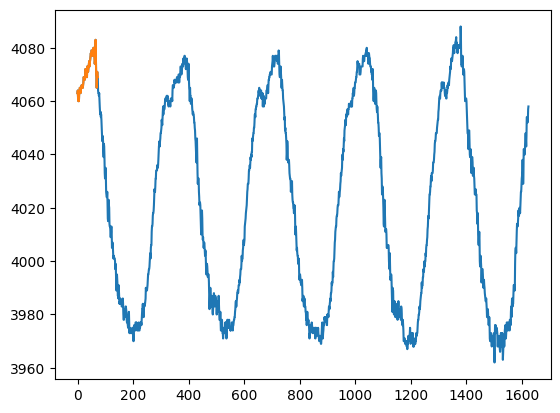


counter : 312537
index : 54101
option : 32
timestamp : 1742873096
trigger_time_tag : 2604721291


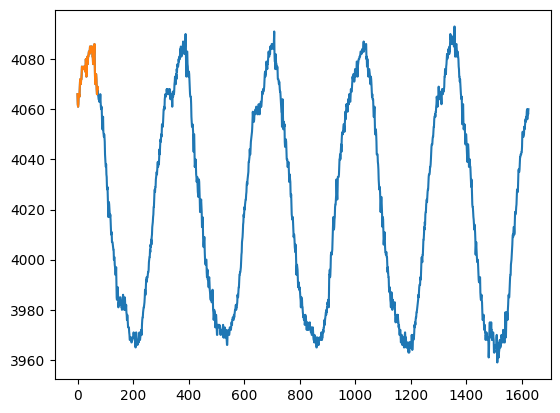


counter : 312543
index : 54102
option : 32
timestamp : 1742873096
trigger_time_tag : 2604722113


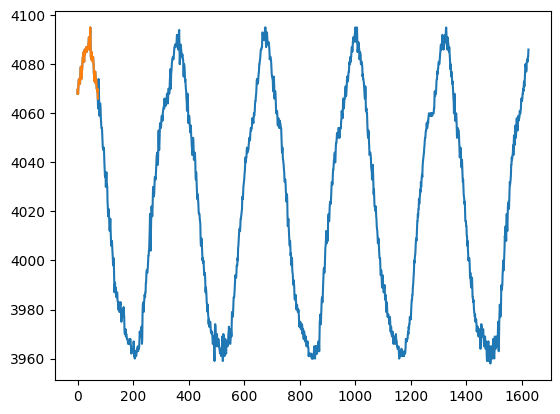


counter : 312549
index : 54103
option : 32
timestamp : 1742873096
trigger_time_tag : 2604722929


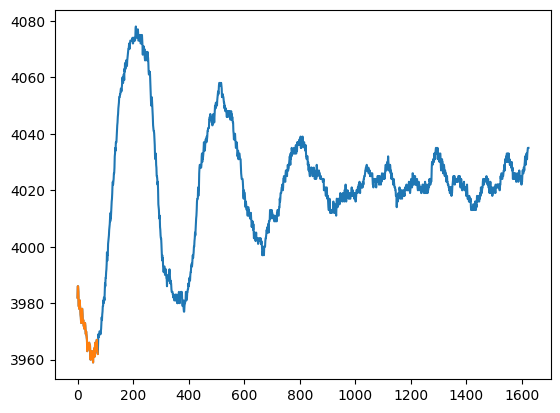


counter : 312558
index : 54104
option : 32
timestamp : 1742873096
trigger_time_tag : 2604723801


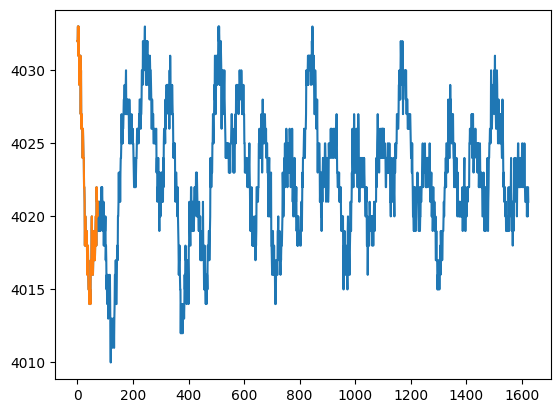


counter : 312563
index : 54105
option : 32
timestamp : 1742873096
trigger_time_tag : 2604724619


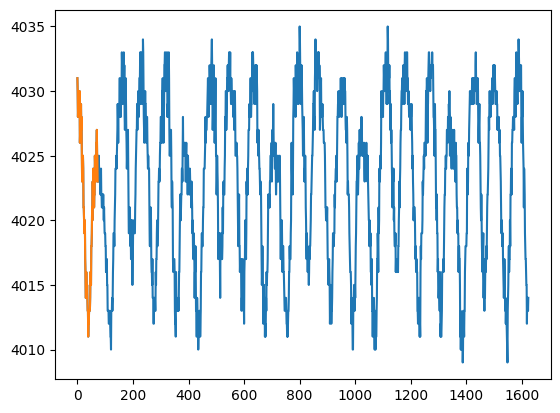


counter : 312564
index : 54106
option : 32
timestamp : 1742873096
trigger_time_tag : 2604727979


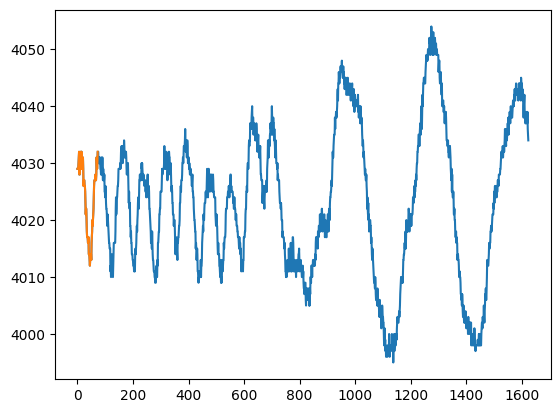


counter : 312572
index : 54107
option : 32
timestamp : 1742873096
trigger_time_tag : 2604728847


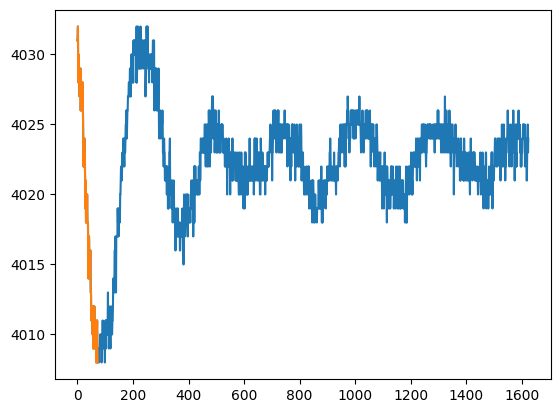


counter : 312587
index : 54108
option : 32
timestamp : 1742873096
trigger_time_tag : 2604729665


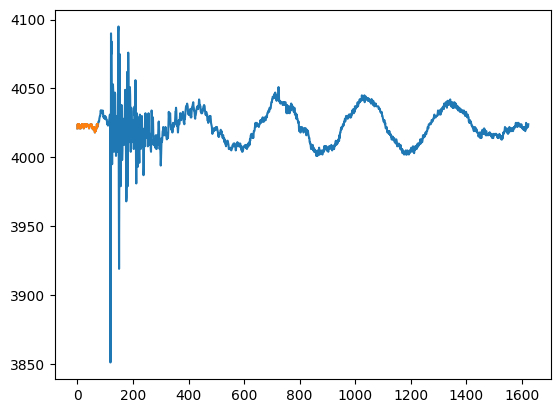


counter : 349649
index : 60611
option : 36
timestamp : 1742873233
trigger_time_tag : 2541563235


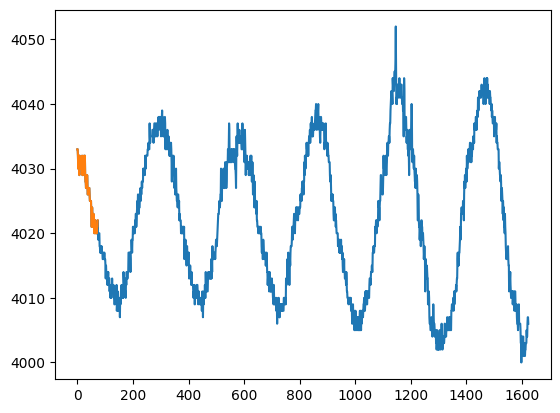


counter : 349672
index : 60612
option : 36
timestamp : 1742873233
trigger_time_tag : 2541564149


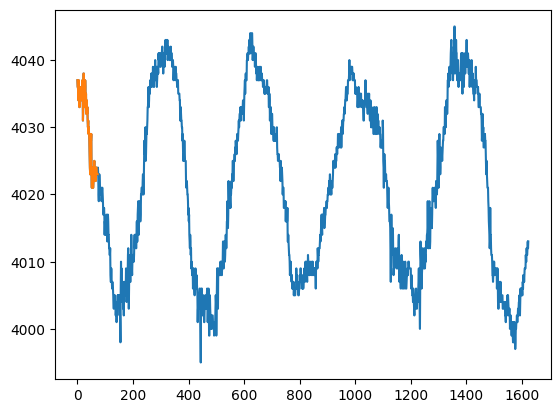


counter : 349689
index : 60613
option : 36
timestamp : 1742873233
trigger_time_tag : 2541565143


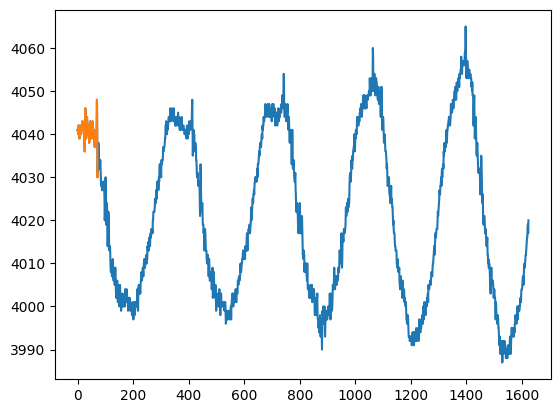

In [11]:
# plot a few problematic events

counter_min = 0
counter_max = 100

for n,(i,j) in enumerate(event_list2):

    if n > counter_min and n <= counter_max:
        
        for k,v in event_attr.items():
            print( k, ":", v )
        
        plt.figure()
        event, event_attr = reader.GetEvent( i )
        plt.plot( event[channel] )
        plt.plot( event[channel][:pre_trigger_window-50] )
        plt.show()

        print()
    
    if n >= counter_max:
        break

- - -
## Time Interval Between Two Triggered Events

If above hypothesis is true, then the two pulses should be very close to each other in time. 

In particular, the trigger clock has 8 ns width, and the time separation should be 10 us => 1250 counts
- get statistics of time difference of trigger time tag between abnormal events and preceeding events
- at the same time, use another list to keep track of events that have unusual time separations

In [9]:
plot_list1 = []
    # for very large values
plot_list2 = []
    # for closer values

ttt_list = []

for i,j in event_list:

    event, event_attr = reader.GetEvent( i )
    ttt1 = np.uint64( event_attr['trigger_time_tag'] )
    ettt1 = event_attr['option']
    
    event, event_attr = reader.GetEvent( i-1 )
    ttt2 = np.uint64( event_attr['trigger_time_tag'] )
    ettt2 = event_attr['option']

    delta = ttt1-ttt2
    if ettt1 > ettt2:
        delta = up.uint64(2**32) - delta

    # very large time separation
    if delta > 10000:
        plot_list1.append( i )
    # moderately large time separation
    elif delta > 1400:
        plot_list2.append( i )
        
    ttt_list.append( delta )

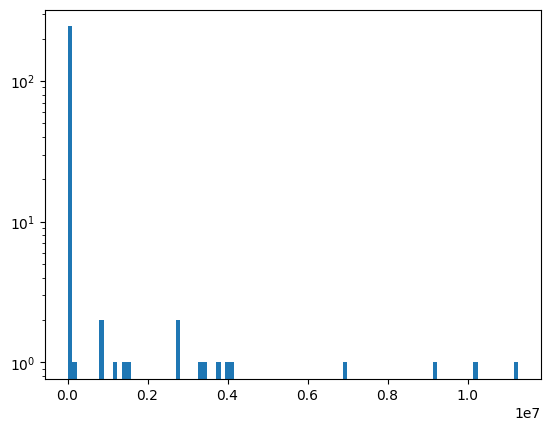

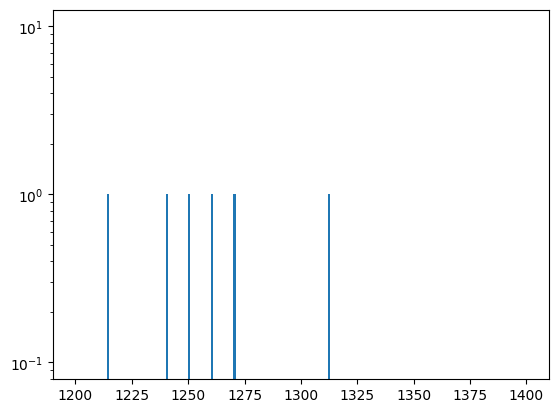

In [10]:
plt.figure()
plt.hist( ttt_list, bins=100);
plt.yscale('log')
plt.show()

plt.figure()
plt.hist( ttt_list, bins=200, range=[1200,1400]);
plt.yscale('log')
plt.show()

- - -
## Check Events with Abnormally Large Time Separation

These events turned out to be those with really large baseline fluctuations, thus there are no temporal correlation (just coincidence)
- probably there is another event preceeding, but since it is too small, it missed the trigger
- the preceeding event made the baseline standard deviation to be larger than usual

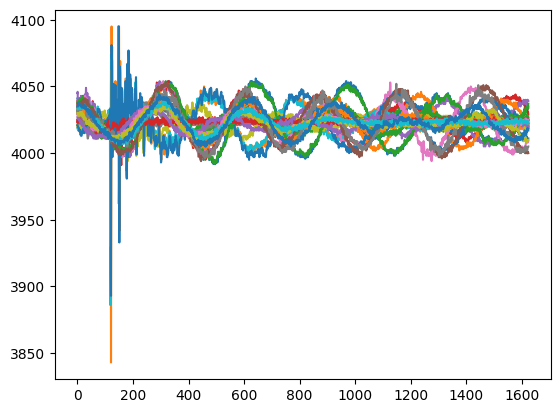

In [12]:
fig = plt.plot()

for id in plot_list1:
    event, event_attr = reader.GetEvent( id )
    plt.plot( event[channel], label = 'event {}'.format(id) )

plt.show()

- - -
## Events with Closer Time Separation
- These events have time separation close to 1250 samples, but not exactly.
- Many of the events are characterized by a pre-existing pulse prior to trigger.
    - **It is possible that the pulse happened while the previous event's acquisition window is just terminated.**

counter : 312279
index : 54080
option : 32
timestamp : 1742873096
trigger_time_tag : 2604687639
counter : 312277
index : 54079
option : 32
timestamp : 1742873096
trigger_time_tag : 2604682853
counter : 312275
index : 54078
option : 32
timestamp : 1742873096
trigger_time_tag : 2604655537


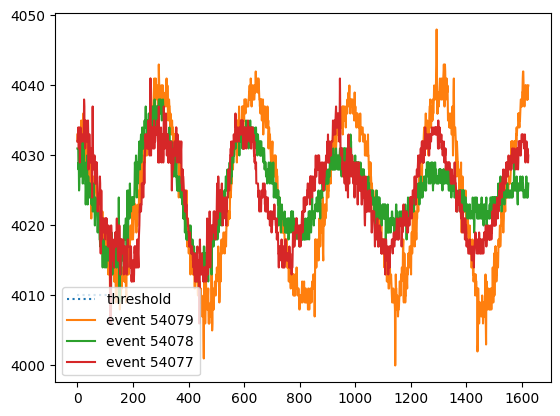

counter : 312564
index : 54106
option : 32
timestamp : 1742873096
trigger_time_tag : 2604727979
counter : 312563
index : 54105
option : 32
timestamp : 1742873096
trigger_time_tag : 2604724619
counter : 312558
index : 54104
option : 32
timestamp : 1742873096
trigger_time_tag : 2604723801


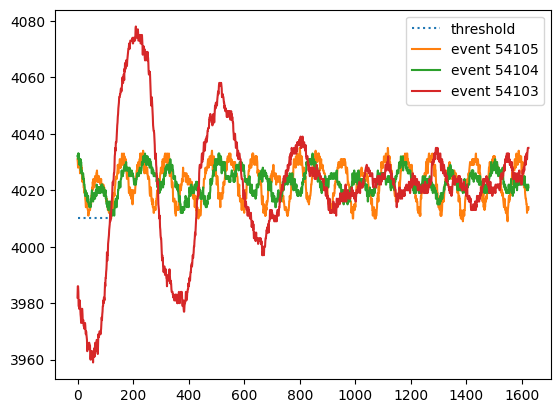

counter : 349726
index : 60616
option : 36
timestamp : 1742873233
trigger_time_tag : 2541569309
counter : 349716
index : 60615
option : 36
timestamp : 1742873233
trigger_time_tag : 2541566843
counter : 349707
index : 60614
option : 36
timestamp : 1742873233
trigger_time_tag : 2541566003


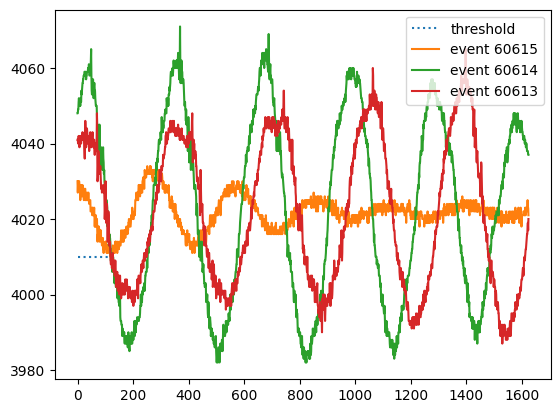

counter : 349727
index : 60617
option : 36
timestamp : 1742873233
trigger_time_tag : 2541577363
counter : 349726
index : 60616
option : 36
timestamp : 1742873233
trigger_time_tag : 2541569309
counter : 349716
index : 60615
option : 36
timestamp : 1742873233
trigger_time_tag : 2541566843


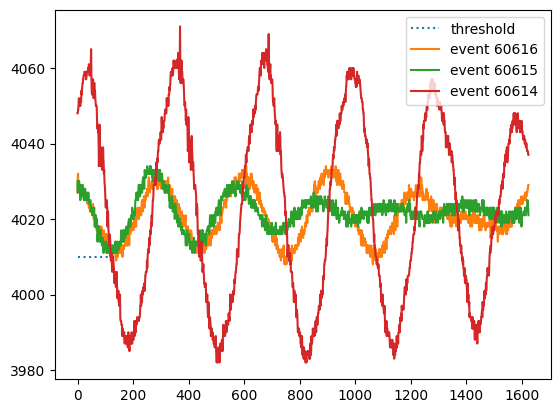

counter : 539038
index : 93795
option : 56
timestamp : 1742873920
trigger_time_tag : 2432684109
counter : 539036
index : 93794
option : 56
timestamp : 1742873920
trigger_time_tag : 2432678917
counter : 539032
index : 93793
option : 56
timestamp : 1742873920
trigger_time_tag : 2432677985


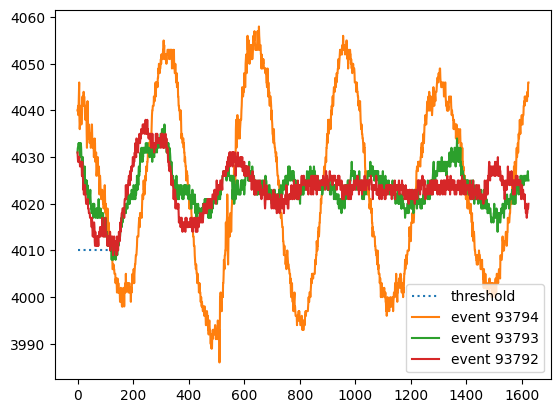

counter : 577915
index : 100513
option : 60
timestamp : 1742874056
trigger_time_tag : 2307990541
counter : 577913
index : 100512
option : 60
timestamp : 1742874056
trigger_time_tag : 2307987905
counter : 577906
index : 100511
option : 60
timestamp : 1742874056
trigger_time_tag : 2307987083


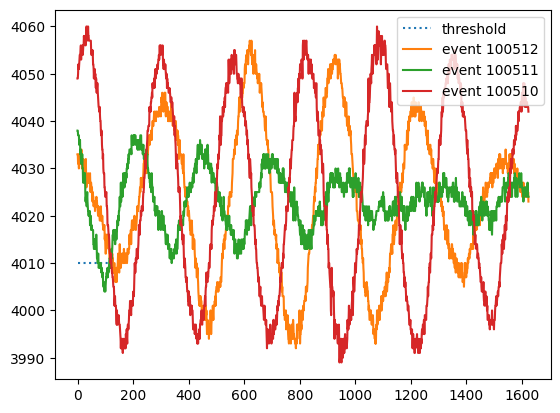

counter : 654186
index : 113825
option : 68
timestamp : 1742874331
trigger_time_tag : 2374812537
counter : 654179
index : 113824
option : 68
timestamp : 1742874331
trigger_time_tag : 2374802899
counter : 654164
index : 113823
option : 68
timestamp : 1742874331
trigger_time_tag : 2374801959


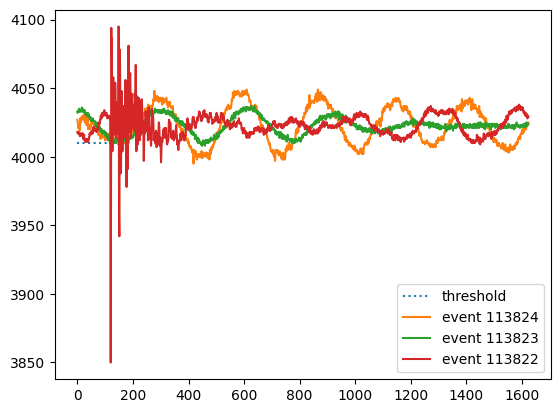

counter : 768082
index : 133639
option : 80
timestamp : 1742874743
trigger_time_tag : 2267450977
counter : 768071
index : 133638
option : 80
timestamp : 1742874743
trigger_time_tag : 2267446899
counter : 768057
index : 133637
option : 80
timestamp : 1742874743
trigger_time_tag : 2266591651


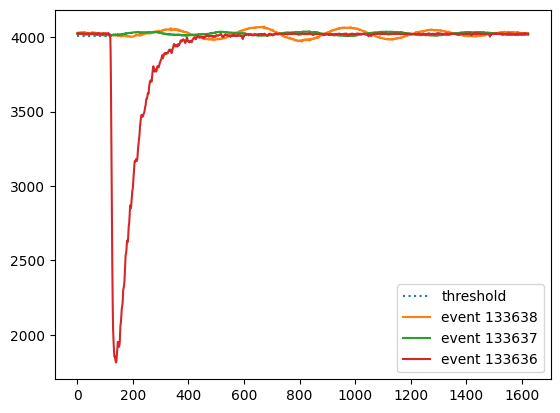

counter : 768096
index : 133640
option : 80
timestamp : 1742874743
trigger_time_tag : 2267452427
counter : 768082
index : 133639
option : 80
timestamp : 1742874743
trigger_time_tag : 2267450977
counter : 768071
index : 133638
option : 80
timestamp : 1742874743
trigger_time_tag : 2267446899


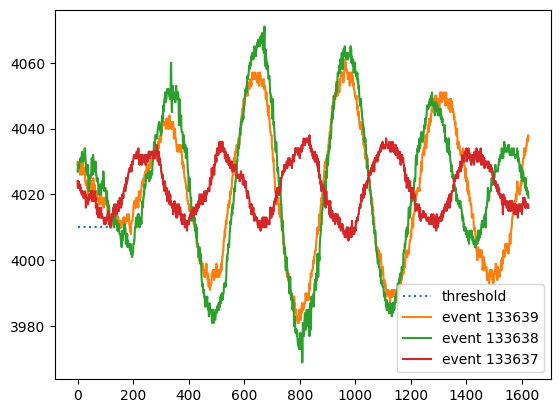

counter : 844433
index : 146973
option : 88
timestamp : 1742875018
trigger_time_tag : 2267109623
counter : 844428
index : 146972
option : 88
timestamp : 1742875018
trigger_time_tag : 2267101927
counter : 844415
index : 146971
option : 88
timestamp : 1742875018
trigger_time_tag : 2267100483


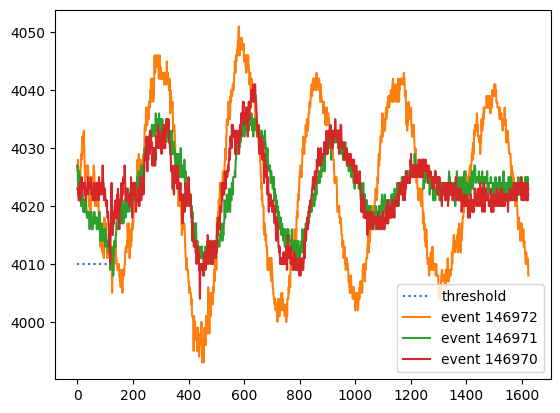

counter : 882647
index : 153619
option : 92
timestamp : 1742875155
trigger_time_tag : 2214061245
counter : 882640
index : 153618
option : 92
timestamp : 1742875155
trigger_time_tag : 2214059737
counter : 882632
index : 153617
option : 92
timestamp : 1742875155
trigger_time_tag : 2214058905


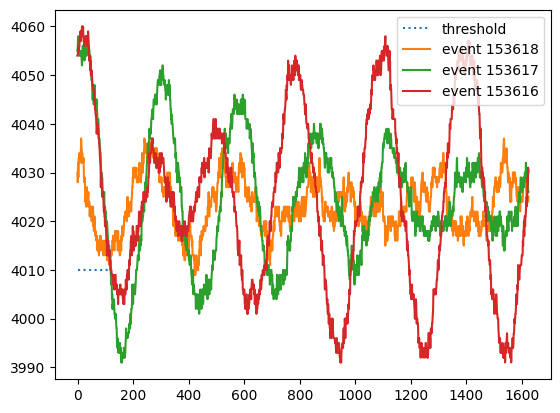

counter : 996785
index : 173574
option : 104
timestamp : 1742875568
trigger_time_tag : 2323648519
counter : 996779
index : 173573
option : 104
timestamp : 1742875568
trigger_time_tag : 2323644507
counter : 996770
index : 173572
option : 104
timestamp : 1742875568
trigger_time_tag : 2323643641


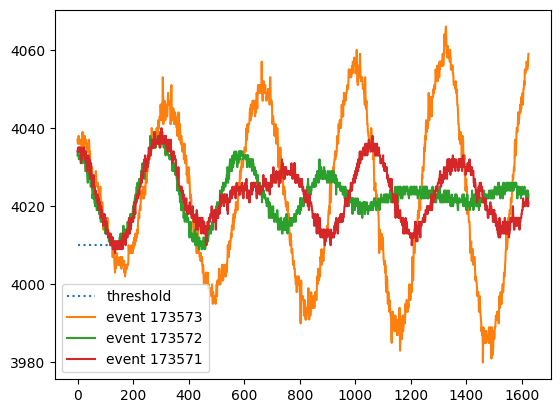

In [13]:
for id in plot_list2:
    
    fig = plt.plot()
    plt.plot( [0,pre_trigger_window], [threshold[channel],threshold[channel]], linestyle = ':', label = 'threshold' )
    
    event, event_attr = reader.GetEvent( id )
    for key, val in event_attr.items():
        print( key, ':', val )
    plt.plot( event[channel], label = 'event {}'.format(id) )

    event, event_attr = reader.GetEvent( id-1 )
    for key, val in event_attr.items():
        print( key, ':', val )
    plt.plot( event[channel], label = 'event {}'.format(id-1) )

    event, event_attr = reader.GetEvent( id-2 )
    for key, val in event_attr.items():
        print( key, ':', val )
    plt.plot( event[channel], label = 'event {}'.format(id-2) )
    #plt.ylim([3900,4030])
    plt.legend()
    plt.show()

# Optimal Trigger Alignment

A few ways will be used to align pulses. The results will be plotted in the very end.

In [14]:
pre = 20
post = 230

result = {}
result['threshold'] = np.zeros( pre+post )
for i in range(1,10):
    result['{}_sigma'.format(i)] = np.zeros( pre+post )

def GetBaseline( array, pre_trig_window, n = 5 ):
    '''
    Returns the mean and standard deviation of the pre-trigger baseline
    '''
    avg = np.average( array[:pre_trig_window-n] )
    dev = np.std( array[:pre_trig_window-n] )
    return avg, dev
    

def GetPulseBegin( array, pre_trig_window, nSigma ):
    '''
    Returns the beginning of the pulse, aligned by the first deviation from baseline by N sigmas
    np.where() method returns a tuple with the first element being an array of indices that satisties the condition
    '''
    mean, dev = GetBaseline( array, pre_trig_window)
    arr_len = len(array[:pre_trig_window])
    return np.where( np.abs(array[:pre_trig_window]-mean*np.ones(arr_len) ) < nSigma * dev)[0][-1]

counter = 0

std_threshold = 1.5
    # only select events with clean baseline

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )

    array_whole = event_data[channel]
    mean, dev = GetBaseline( array_whole, pre_trigger_window )

    if dev > std_threshold:
        continue
        
    array_whole =  mean * np.ones( len(array_whole) ) - array_whole
        # use the entire array to calculate mean and fluctuation

    # partial array used for output
    array_part = array_whole[pre_trigger_window - pre : pre_trigger_window + post]
    
    # the case for simple threshold trigger
    result['threshold'] += array_part / np.max(array_part)

    # alignment based on n-sigma
    for i in range(1,10):
        begin = GetPulseBegin( array_whole, pre_trigger_window, i )
        tmp = array_whole[ begin - pre : begin + post ]
        result['{}_sigma'.format(i)] += tmp/np.max(tmp)
            
    counter += 1

    if counter >= 10000:
        break

for key, val in result.items():
    val /= counter

Processing event 14471

1_sigma 1.4505340727763603
2_sigma 2.587208693803852
3_sigma 6.205972308319447
4_sigma 6.591102808552199
5_sigma 6.639545793300519
6_sigma 6.6706399027230745
7_sigma 6.309931835300741
8_sigma 5.9925103168532825
9_sigma 3.5608658528815003


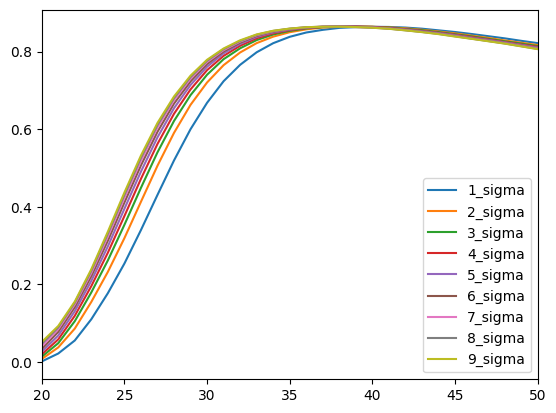

In [15]:
def calculate_rise_time(waveform, timebase):
    """
    Calculate the rise time (10% to 90%) of a monotonically increasing waveform using linear interpolation.

    Parameters:
        waveform (np.array): The waveform data.
        timebase (np.array): Time values corresponding to each waveform point.

    Returns:
        float: Rise time in the same unit as timebase.
    """
    # Determine 10% and 90% levels
    min_val, max_val = waveform[0], waveform[-1]
    ten_percent = min_val + 0.05 * (max_val - min_val)
    ninety_percent = min_val + 0.95 * (max_val - min_val)

    # Find the surrounding points for 10% and 90% crossings
    idx_10 = np.argmax(waveform >= ten_percent)
    idx_90 = np.argmax(waveform >= ninety_percent)

    # Linear interpolation for finer time precision
    t10 = np.interp(ten_percent, waveform[idx_10-1:idx_10+1], timebase[idx_10-1:idx_10+1])
    t90 = np.interp(ninety_percent, waveform[idx_90-1:idx_90+1], timebase[idx_90-1:idx_90+1])

    # Return the refined rise time
    return t90 - t10

plt.figure()

for key, val in result.items():
    if key == 'threshold':
        #plt.plot( np.arange(len(val))+8, val, label = key )
        continue
    else:
        plt.plot( np.arange(len(val)), val, label = key )

    print( key, calculate_rise_time(val, np.arange(len(val) ) ) )

plt.xlim([20,50])
plt.legend()
plt.show()

In [14]:
reader.Close()